In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_excel("/home/mahaputra777/pt_skp/dataset/Reservation_Report_01_May_2025_to_30_June 2026_1782181807.xls")


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Reservation Date  1495 non-null   object 
 1   Folio             1494 non-null   float64
 2   Reference No      801 non-null    object 
 3   Room Type         1494 non-null   object 
 4   Room              1494 non-null   object 
 5   Rates             1494 non-null   object 
 6   Guest             1494 non-null   object 
 7   Date of Birth     0 non-null      float64
 8   Guest Email       905 non-null    object 
 9   Nationality       482 non-null    object 
 10  Country           1275 non-null   object 
 11  Province          0 non-null      float64
 12  City              0 non-null      float64
 13  Arrival           1494 non-null   object 
 14  Departure         1494 non-null   object 
 15  Nights            1495 non-null   int64  
 16  Agent             1494 non-null   object 


# ALL

In [33]:
import pandas as pd

# Asumsi df sudah di-load seperti kode Anda:
# df = pd.read_excel("/home/mahaputra971/pt_skp/dataset/reservation_14_4_2026.xls")

# 1. Pastikan kolom 'Reservation Date' bertipe datetime
if 'Reservation Date' not in df.columns:
    if 'Date' in df.columns:
        df['Reservation Date'] = df['Date']
    else:
        raise KeyError("Kolom 'Reservation Date' tidak ditemukan dan kolom 'Date' juga tidak ada.")

df = df[df['Reservation Date'] != 'Total'].copy()
df['Reservation Date'] = pd.to_datetime(df['Reservation Date'])

# 2. Pisahkan menjadi 2 DataFrame berdasarkan tahun
df_2025 = df[df['Reservation Date'].dt.year == 2025].copy()
df_2026 = df[df['Reservation Date'].dt.year == 2026].copy()

# (Opsional) Cek jumlah baris pada masing-masing dataframe baru
print(f"Jumlah data 2025: {len(df_2025)}")
print(f"Jumlah data 2026: {len(df_2026)}")

Jumlah data 2025: 839
Jumlah data 2026: 655


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1494 entries, 0 to 1493
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Reservation Date  1494 non-null   datetime64[ns]
 1   Folio             1494 non-null   float64       
 2   Reference No      801 non-null    object        
 3   Room Type         1494 non-null   object        
 4   Room              1494 non-null   object        
 5   Rates             1494 non-null   object        
 6   Guest             1494 non-null   object        
 7   Date of Birth     0 non-null      float64       
 8   Guest Email       905 non-null    object        
 9   Nationality       482 non-null    object        
 10  Country           1275 non-null   object        
 11  Province          0 non-null      float64       
 12  City              0 non-null      float64       
 13  Arrival           1494 non-null   object        
 14  Departure         1494 non-nu

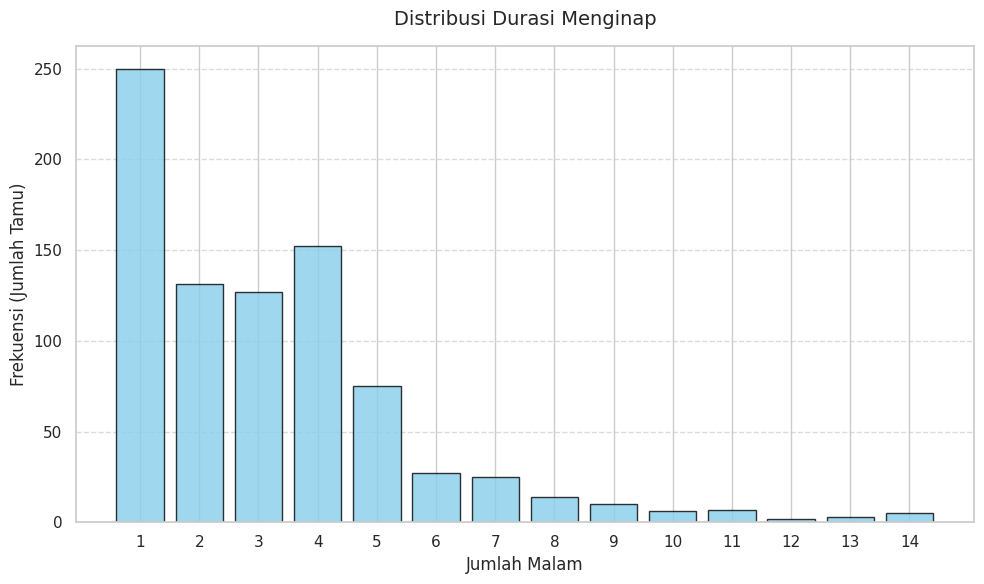

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Memfilter data
if 'Nights' in df_2025.columns:
    stay = df_2025.loc[df_2025['Nights'] < 15, 'Nights']
else:
    stay = df_2025.loc[df_2025['Room Sold'] < 15, 'Room Sold']

plt.figure(figsize=(10, 6))

# Perbaikan 1: Tentukan bin secara eksplisit agar batang berada tepat di tengah angka
# Kita buat range dari 1 sampai 15 agar angka 14 tercover penuh
bins = np.arange(1, 16) - 0.5 

plt.hist(stay, bins=bins, rwidth=0.8, color='skyblue', edgecolor='black', alpha=0.8)

# Perbaikan 2: Paksa sumbu X menampilkan setiap angka (1, 2, 3... 14)
plt.xticks(range(1, 15))

# Perbaikan 3: Estetika Tambahan
plt.title("Distribusi Durasi Menginap", fontsize=14, pad=15)
plt.xlabel("Jumlah Malam", fontsize=12)
plt.ylabel("Frekuensi (Jumlah Tamu)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Grid hanya horizontal agar lebih bersih

plt.tight_layout()
plt.show()

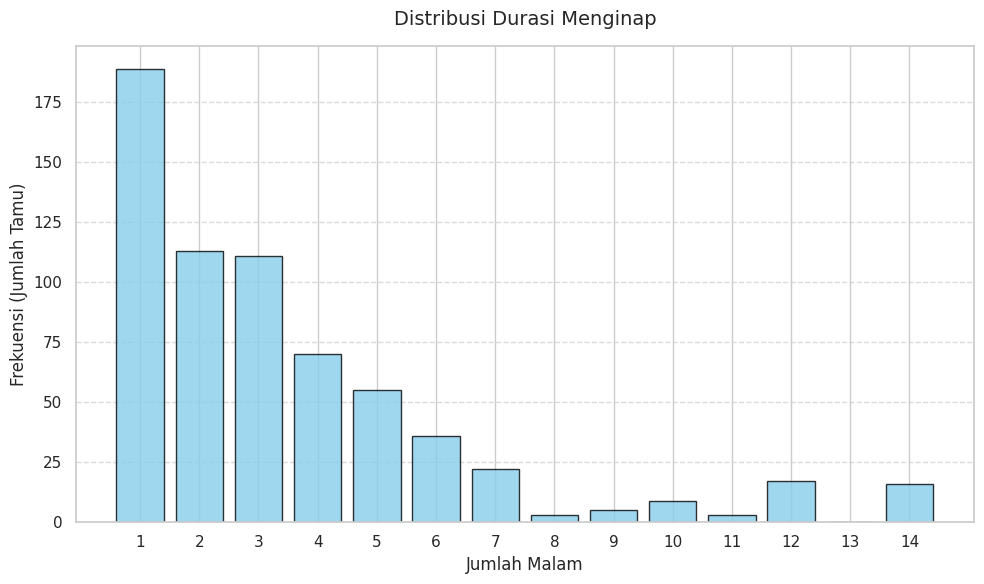

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Memfilter data
stay = df_2026[df_2026['Nights'] < 15]['Nights']

plt.figure(figsize=(10, 6))

# Perbaikan 1: Tentukan bin secara eksplisit agar batang berada tepat di tengah angka
# Kita buat range dari 1 sampai 15 agar angka 14 tercover penuh
bins = np.arange(1, 16) - 0.5 

plt.hist(stay, bins=bins, rwidth=0.8, color='skyblue', edgecolor='black', alpha=0.8)

# Perbaikan 2: Paksa sumbu X menampilkan setiap angka (1, 2, 3... 14)
plt.xticks(range(1, 15))

# Perbaikan 3: Estetika Tambahan
plt.title("Distribusi Durasi Menginap", fontsize=14, pad=15)
plt.xlabel("Jumlah Malam", fontsize=12)
plt.ylabel("Frekuensi (Jumlah Tamu)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Grid hanya horizontal agar lebih bersih

plt.tight_layout()
plt.show()

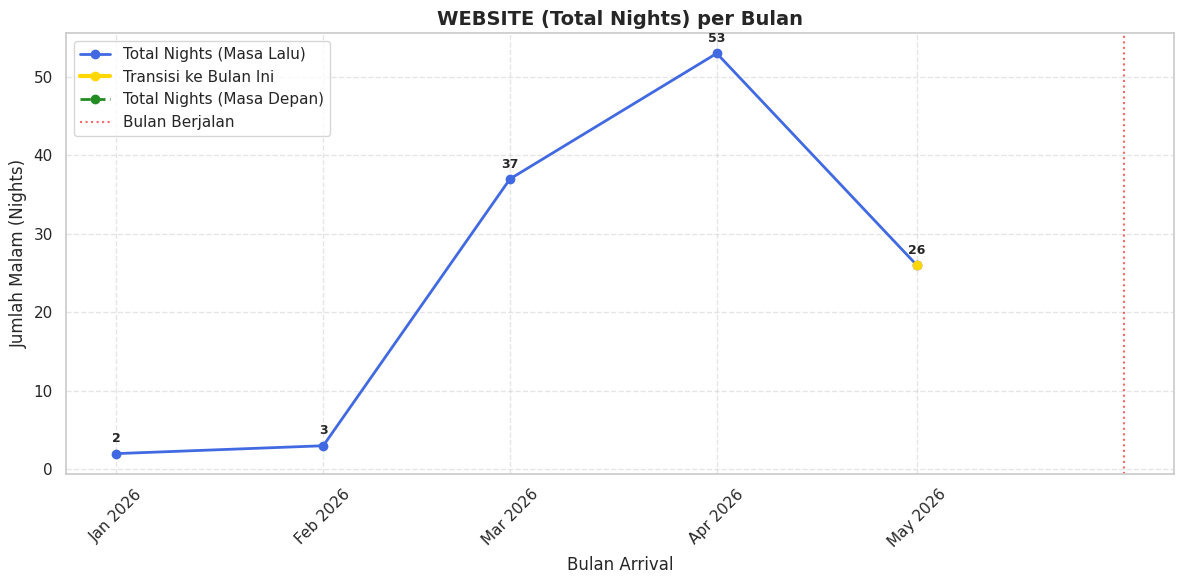

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pandas.tseries.offsets import MonthBegin

df_doku = df[df['Agent'] == 'Doku.'].copy()

# 1. Pastikan kolom Reservation Date menjadi tipe datetime
df_doku['Reservation Date'] = pd.to_datetime(df_doku['Reservation Date'])
df_doku_2026 = df_doku[df_doku['Reservation Date'].dt.year == 2026].copy()

# 2. Agregasi data: Menjumlahkan (SUM) kolom 'Nights' per bulan
monthly_nights = df_doku_2026.groupby(df_doku_2026['Reservation Date'].dt.to_period('M'))['Nights'].sum()
monthly_nights.index = monthly_nights.index.to_timestamp()

# 3. Tentukan batas waktu (Berdasarkan waktu sekarang)
# Misal hari ini Feb 2026, maka this_month adalah 2026-02-01
this_month = pd.Timestamp(datetime.now()).replace(day=1, hour=0, minute=0, second=0, microsecond=0)
last_month = this_month - MonthBegin(1)

# 4. Memisahkan segmen data untuk pewarnaan
# Segmen Biru: Histori sampai bulan lalu
past_blue = monthly_nights[monthly_nights.index <= last_month]

# Segmen Kuning: Transisi dari bulan lalu ke bulan ini
transition_yellow = monthly_nights[(monthly_nights.index >= last_month) & 
                                   (monthly_nights.index <= this_month)]

# Segmen Hijau: Proyeksi masa depan dari bulan ini ke depan
future_green = monthly_nights[monthly_nights.index >= this_month]

# 5. Membuat Plot
plt.figure(figsize=(12, 6))

# Plot Masa Lalu (Biru)
plt.plot(past_blue.index, past_blue.values, marker='o', linestyle='-', color='royalblue', 
         label='Total Nights (Masa Lalu)', linewidth=2)

# Plot Transisi (Kuning)
plt.plot(transition_yellow.index, transition_yellow.values, marker='o', linestyle='-', 
         color='gold', label='Transisi ke Bulan Ini', linewidth=3)

# Plot Masa Depan (Hijau)
plt.plot(future_green.index, future_green.values, marker='o', linestyle='--', 
         color='forestgreen', label='Total Nights (Masa Depan)', linewidth=2)

# Menambahkan Label Angka (Total Nights) di setiap titik
for x, y in monthly_nights.items():
    plt.text(x, y + (max(monthly_nights)*0.02), f'{int(y)}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Elemen Estetik
plt.title('WEBSITE (Total Nights) per Bulan', fontsize=14, fontweight='bold')
plt.xlabel('Bulan Arrival', fontsize=12)
plt.ylabel('Jumlah Malam (Nights)', fontsize=12)
plt.axvline(x=this_month, color='red', linestyle=':', alpha=0.6, label='Bulan Berjalan')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Format tanggal di sumbu X
plt.xticks(monthly_nights.index, monthly_nights.index.strftime('%b %Y'), rotation=45)

plt.tight_layout()
plt.show()

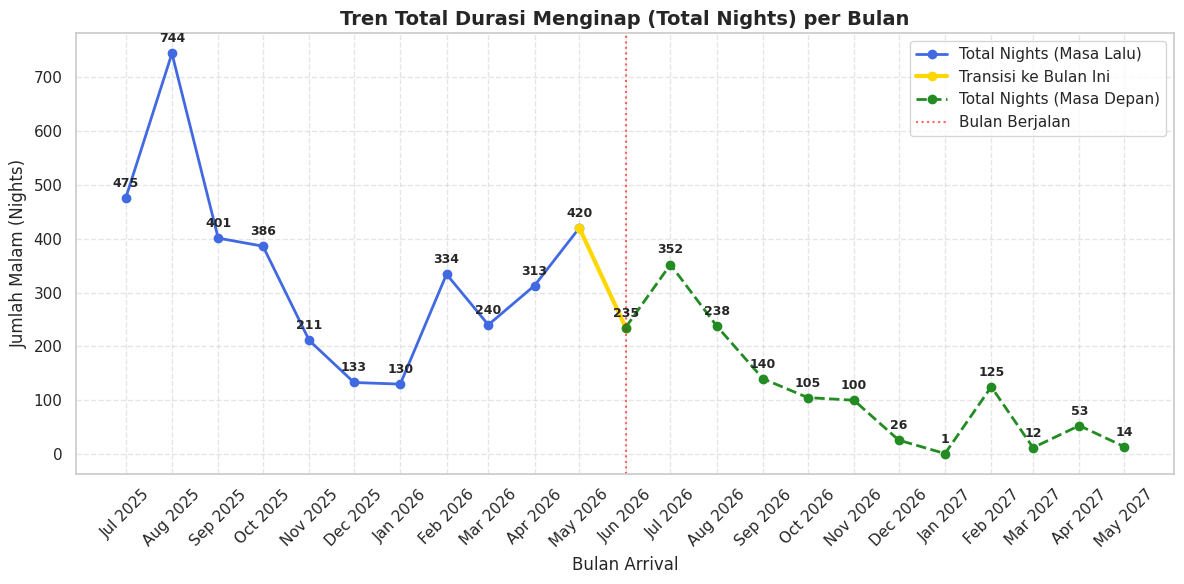

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pandas.tseries.offsets import MonthBegin

# 1. Pastikan kolom Arrival menjadi tipe datetime
df['Arrival'] = pd.to_datetime(df['Arrival'])

# 2. Agregasi data: Menjumlahkan (SUM) kolom 'Nights' per bulan
monthly_nights = df.groupby(df['Arrival'].dt.to_period('M'))['Nights'].sum()
monthly_nights.index = monthly_nights.index.to_timestamp()

# 3. Tentukan batas waktu (Berdasarkan waktu sekarang)
# Misal hari ini Feb 2026, maka this_month adalah 2026-02-01
this_month = pd.Timestamp(datetime.now()).replace(day=1, hour=0, minute=0, second=0, microsecond=0)
last_month = this_month - MonthBegin(1)

# 4. Memisahkan segmen data untuk pewarnaan
# Segmen Biru: Histori sampai bulan lalu
past_blue = monthly_nights[monthly_nights.index <= last_month]

# Segmen Kuning: Transisi dari bulan lalu ke bulan ini
transition_yellow = monthly_nights[(monthly_nights.index >= last_month) & 
                                   (monthly_nights.index <= this_month)]

# Segmen Hijau: Proyeksi masa depan dari bulan ini ke depan
future_green = monthly_nights[monthly_nights.index >= this_month]

# 5. Membuat Plot
plt.figure(figsize=(12, 6))

# Plot Masa Lalu (Biru)
plt.plot(past_blue.index, past_blue.values, marker='o', linestyle='-', color='royalblue', 
         label='Total Nights (Masa Lalu)', linewidth=2)

# Plot Transisi (Kuning)
plt.plot(transition_yellow.index, transition_yellow.values, marker='o', linestyle='-', 
         color='gold', label='Transisi ke Bulan Ini', linewidth=3)

# Plot Masa Depan (Hijau)
plt.plot(future_green.index, future_green.values, marker='o', linestyle='--', 
         color='forestgreen', label='Total Nights (Masa Depan)', linewidth=2)

# Menambahkan Label Angka (Total Nights) di setiap titik
for x, y in monthly_nights.items():
    plt.text(x, y + (max(monthly_nights)*0.02), f'{int(y)}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Elemen Estetik
plt.title('Tren Total Durasi Menginap (Total Nights) per Bulan', fontsize=14, fontweight='bold')
plt.xlabel('Bulan Arrival', fontsize=12)
plt.ylabel('Jumlah Malam (Nights)', fontsize=12)
plt.axvline(x=this_month, color='red', linestyle=':', alpha=0.6, label='Bulan Berjalan')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Format tanggal di sumbu X
plt.xticks(monthly_nights.index, monthly_nights.index.strftime('%b %Y'), rotation=45)

plt.tight_layout()
plt.show()

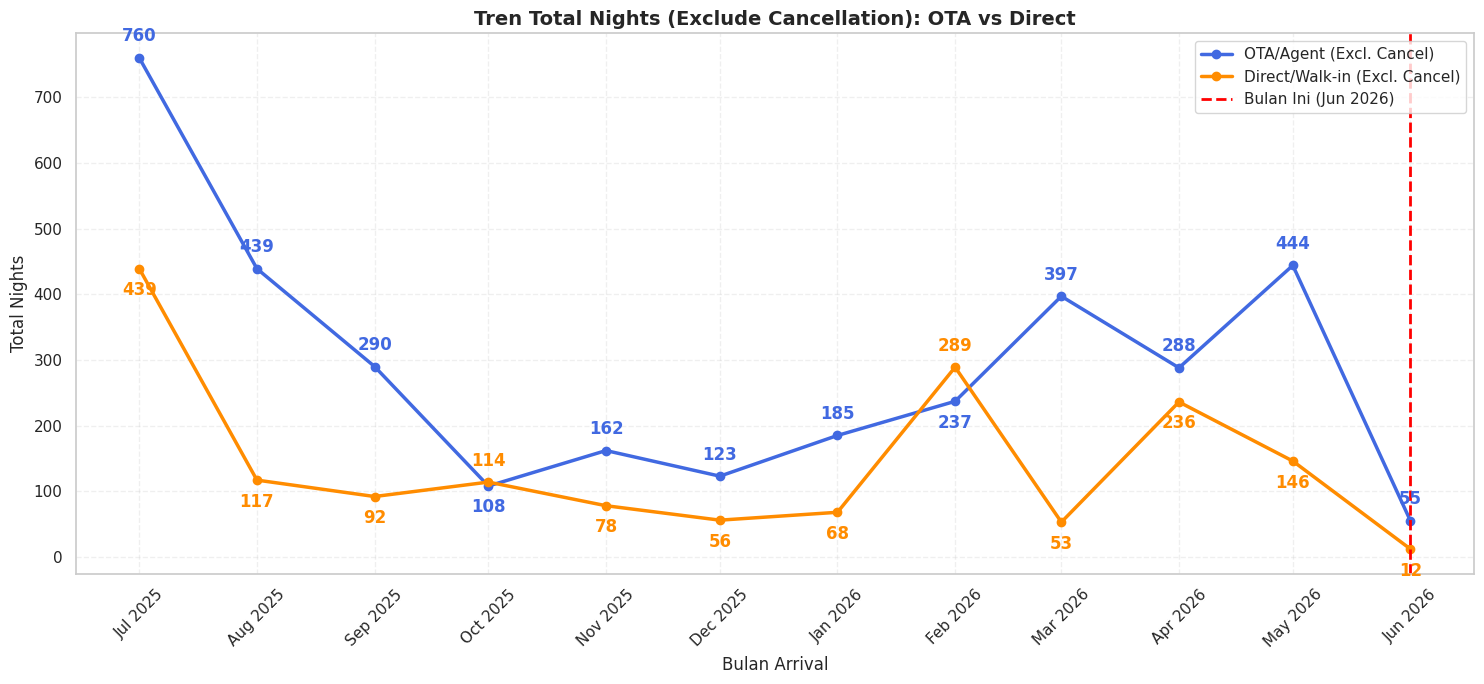

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Pastikan kolom Arrival menjadi tipe datetime
df['Reservation Date'] = pd.to_datetime(df['Reservation Date'])

# 2. Definisikan kategori filter
direct_categories = ['DIRECT', 'WALK IN']
status_exclude = ['CANCELLATION'] # Tambahkan status yang ingin dibuang

# 3. Filter DataFrame Utama: Hapus data CANCELLATION terlebih dahulu
df_active = df[~df['Status'].isin(status_exclude)].copy()

# 4. Pisahkan dataframe berdasarkan kategori Agent dari data yang sudah difilter statusnya
df_direct = df_active[df_active['Agent'].isin(direct_categories)].copy()
df_exclude_direct = df_active[~df_active['Agent'].isin(direct_categories)].copy()

# 5. Agregasi: Total Nights per bulan
all_months = sorted(df_active['Reservation Date'].dt.to_period('M').unique())

trend_exclude = df_exclude_direct.groupby(
    df_exclude_direct['Reservation Date'].dt.to_period('M'))['Nights'].sum().reindex(all_months, fill_value=0)

trend_only_direct = df_direct.groupby(
    df_direct['Reservation Date'].dt.to_period('M'))['Nights'].sum().reindex(all_months, fill_value=0)

# Konversi ke timestamp untuk plotting
trend_exclude.index = trend_exclude.index.to_timestamp()
trend_only_direct.index = trend_only_direct.index.to_timestamp()

# 6. Tentukan Bulan Ini untuk Garis Penanda
today = pd.Timestamp(datetime.now()).replace(day=1, hour=0, minute=0, second=0, microsecond=0)

# 7. Membuat Plot
plt.figure(figsize=(15, 7))

# Plot Garis Biru (OTA/Agent - Exclude Cancellation)
plt.plot(trend_exclude.index, trend_exclude.values, marker='o', 
         linestyle='-', color='royalblue', label='OTA/Agent (Excl. Cancel)', linewidth=2.5)

# Plot Garis Oranye (Direct/Walk-in - Exclude Cancellation)
plt.plot(trend_only_direct.index, trend_only_direct.values, marker='o', 
         linestyle='-', color='darkorange', label='Direct/Walk-in (Excl. Cancel)', linewidth=2.5)

# Garis Penanda Bulan Ini
plt.axvline(x=today, color='red', linestyle='--', linewidth=2, label=f'Bulan Ini ({today.strftime("%b %Y")})')

# 8. LOGIKA ANTI-TUMPANG TINDIH UNTUK LABEL ANGKA
max_val = max(trend_exclude.max(), trend_only_direct.max()) if not trend_exclude.empty else 100
offset = max_val * 0.025

for i in range(len(trend_exclude)):
    val_exclude = trend_exclude.values[i]
    val_direct = trend_only_direct.values[i]
    x_pos = trend_exclude.index[i]
    
    if val_exclude >= val_direct:
        plt.text(x_pos, val_exclude + offset, f'{int(val_exclude)}', color='royalblue', ha='center', va='bottom', fontweight='bold')
        plt.text(x_pos, val_direct - offset, f'{int(val_direct)}', color='darkorange', ha='center', va='top', fontweight='bold')
    else:
        plt.text(x_pos, val_direct + offset, f'{int(val_direct)}', color='darkorange', ha='center', va='bottom', fontweight='bold')
        plt.text(x_pos, val_exclude - offset, f'{int(val_exclude)}', color='royalblue', ha='center', va='top', fontweight='bold')

# Elemen Estetik
plt.title('Tren Total Nights (Exclude Cancellation): OTA vs Direct', fontsize=14, fontweight='bold')
plt.xlabel('Bulan Arrival', fontsize=12)
plt.ylabel('Total Nights', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right')

# Format tanggal di sumbu X
plt.xticks(trend_exclude.index, trend_exclude.index.strftime('%b %Y'), rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_14360/2435142551.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=lead_time_vol.index, y=lead_time_vol.values, palette="Blues_d")


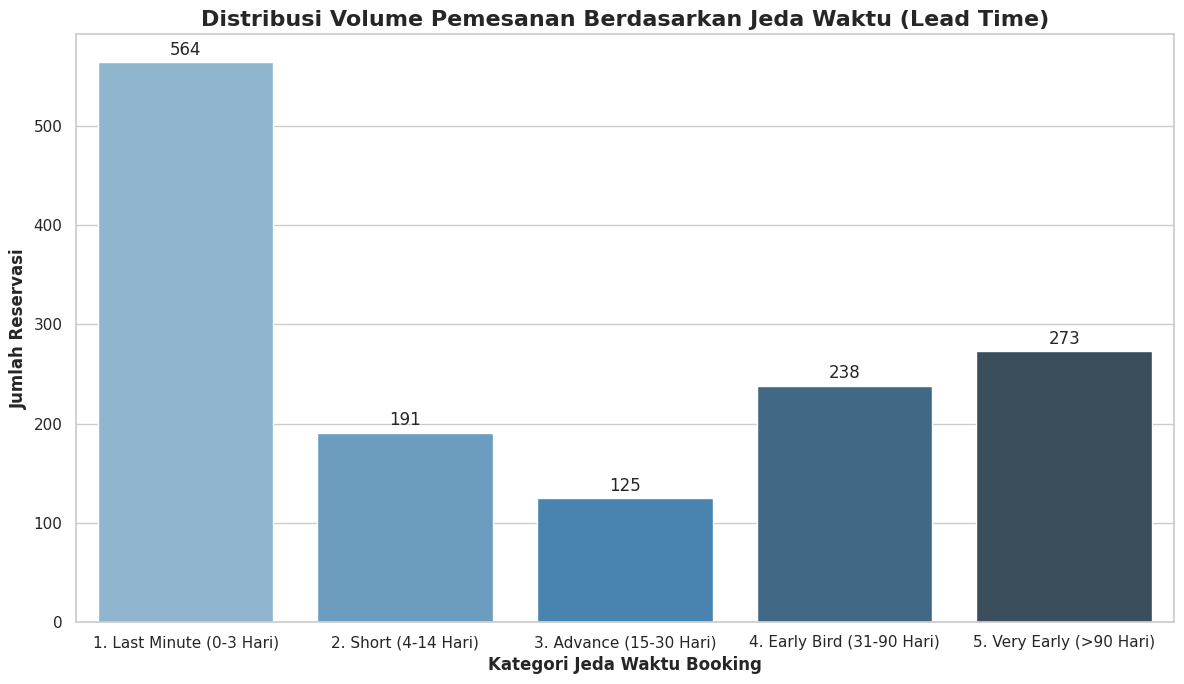

/tmp/ipykernel_14360/2435142551.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_df = df.groupby('Lead Time Category')['Status'].value_counts(normalize=True).unstack().fillna(0) * 100
/tmp/ipykernel_14360/2435142551.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_count = df.groupby('Lead Time Category')['Status'].value_counts().unstack().fillna(0)


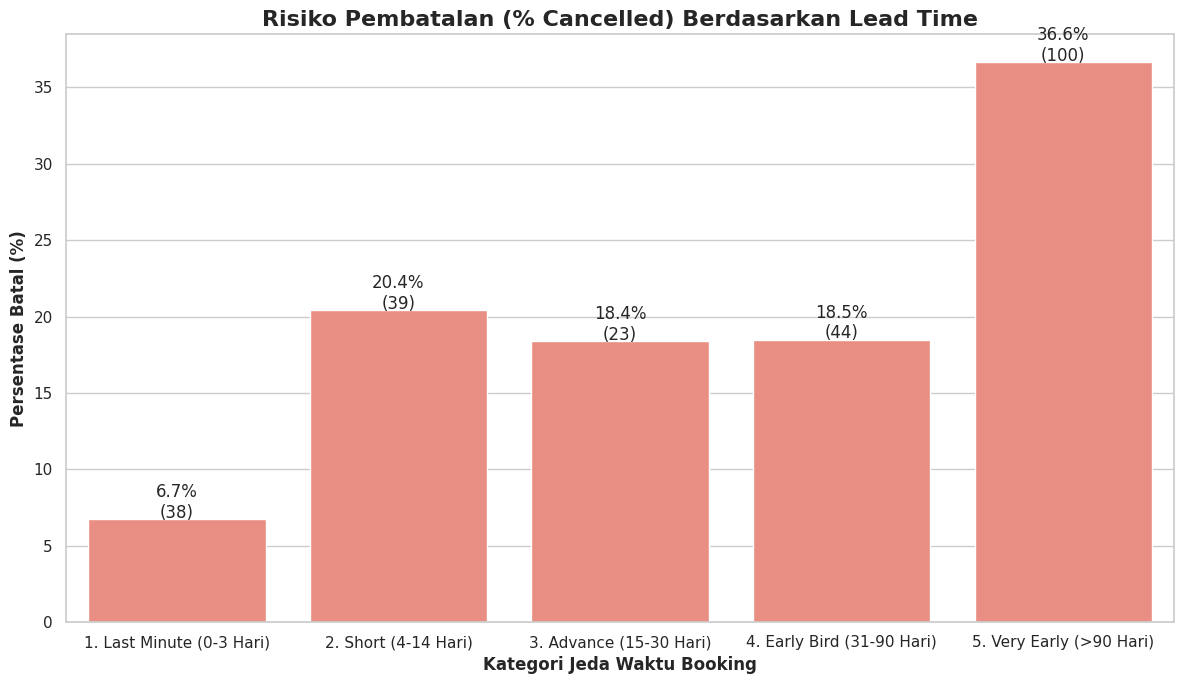

/tmp/ipykernel_14360/2435142551.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(x=top_countries_rev.values, y=top_countries_rev.index, palette="viridis")


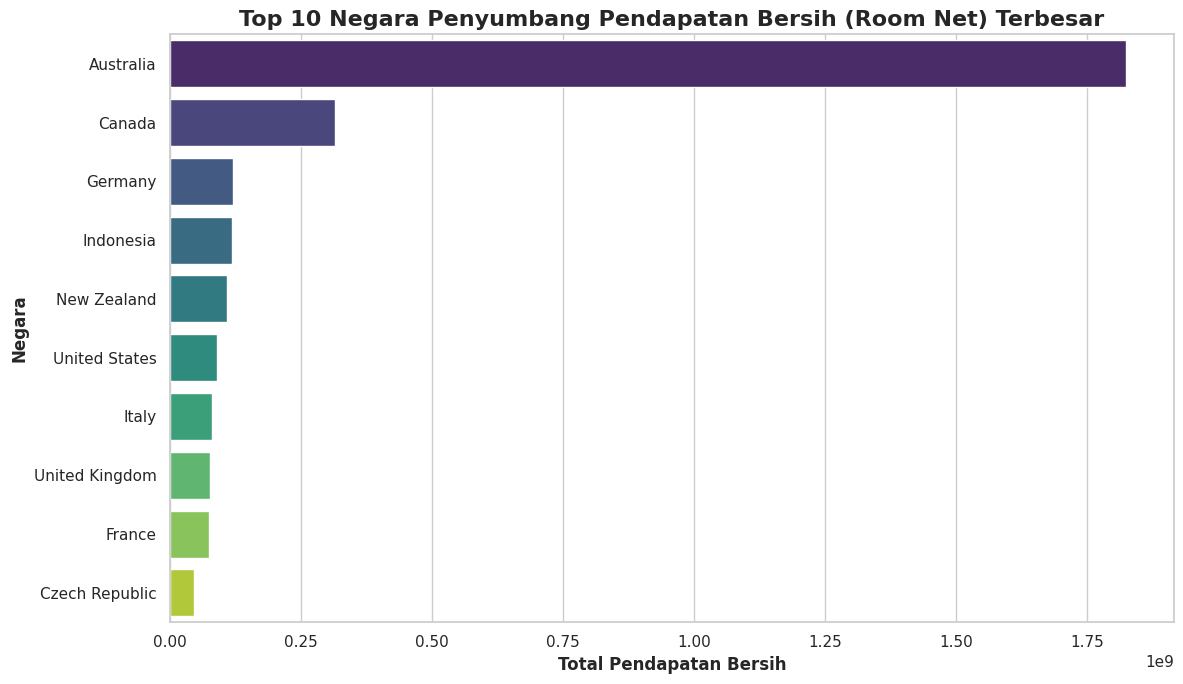

/tmp/ipykernel_14360/2435142551.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(x=top_agents.values, y=top_agents.index, palette="magma")


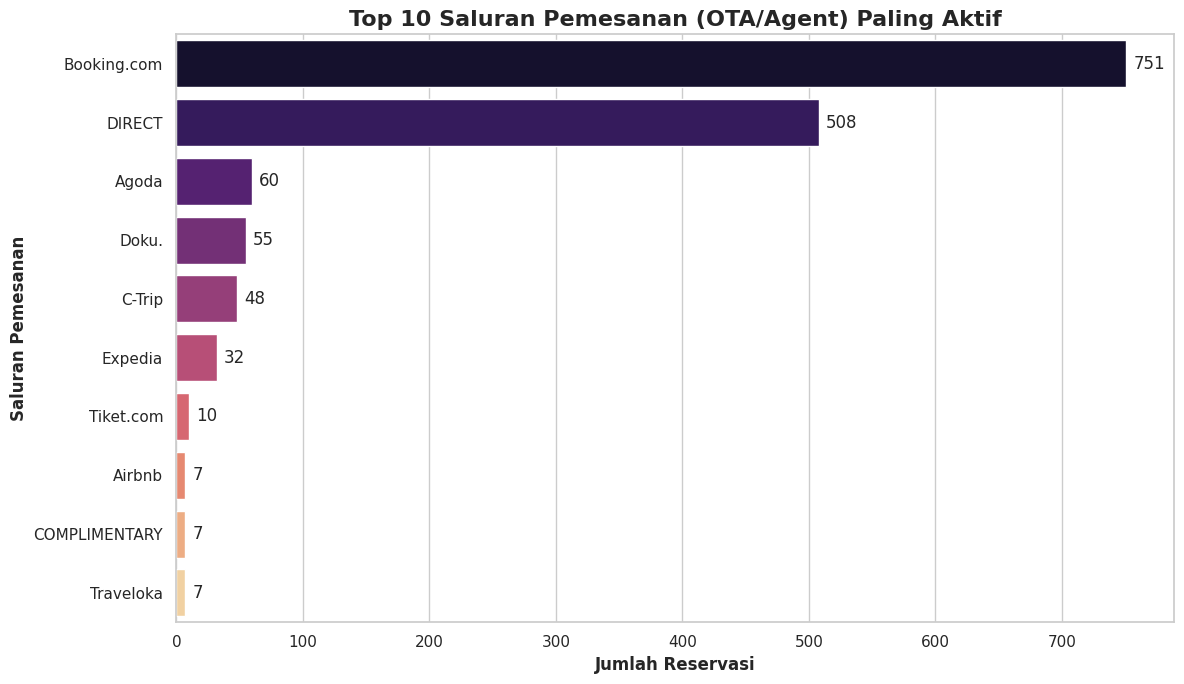

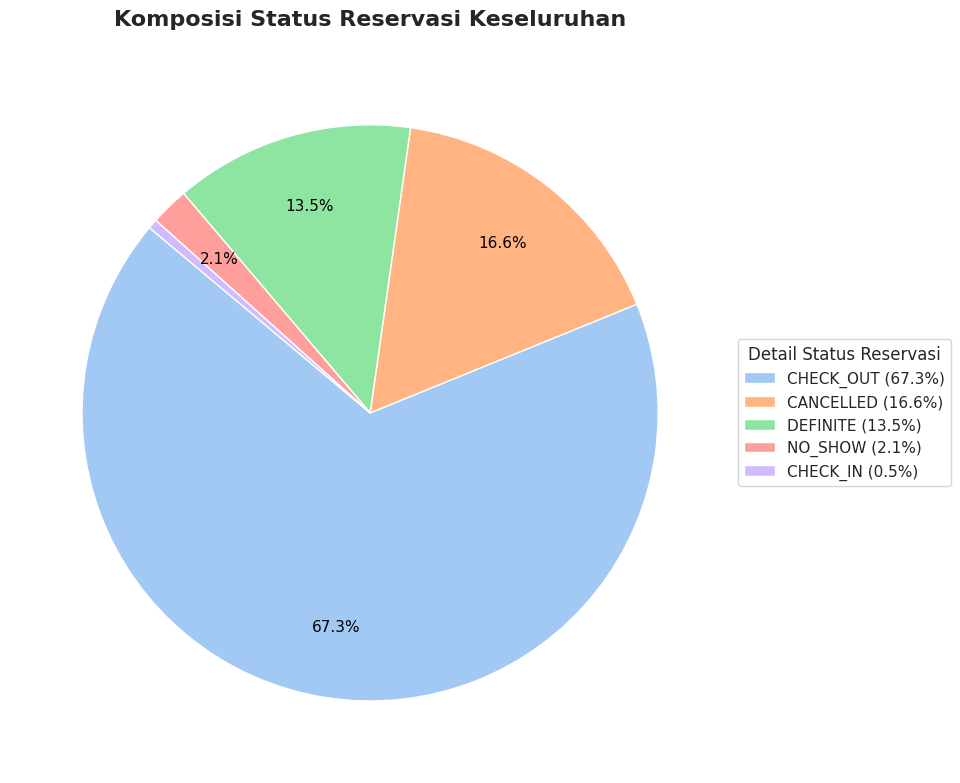

/tmp/ipykernel_14360/2435142551.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax6 = sns.barplot(x=ancillary_perf.values, y=ancillary_perf.index, palette="rocket")


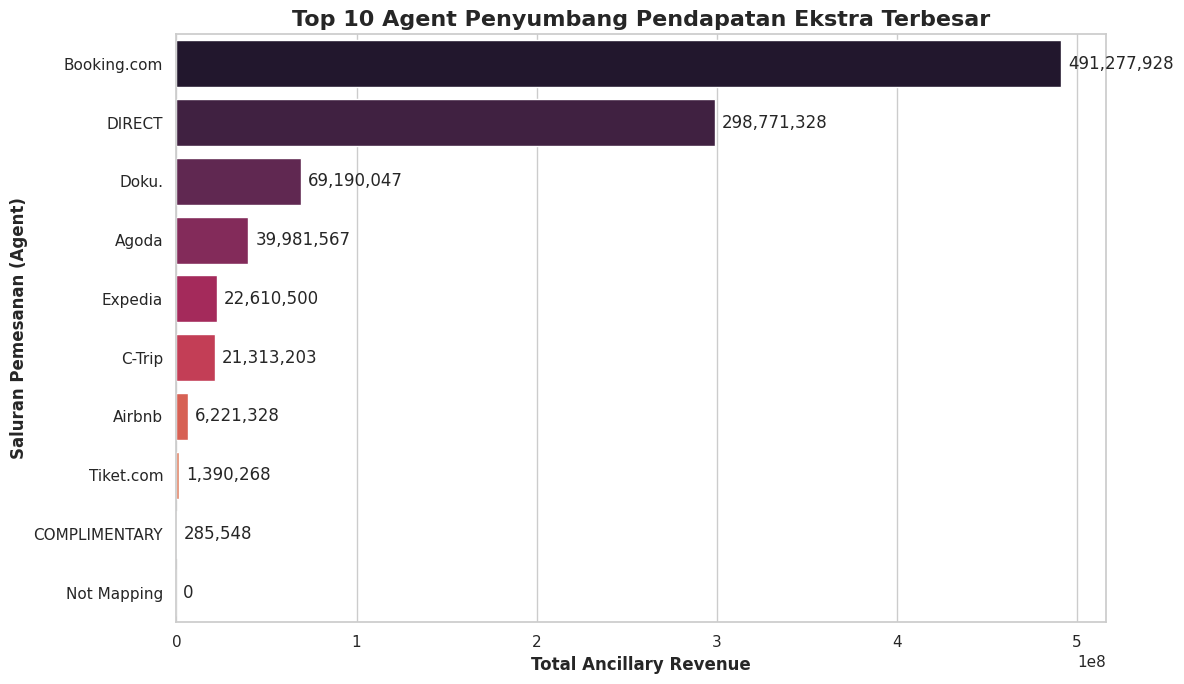

/tmp/ipykernel_14360/2435142551.py:204: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax7 = sns.barplot(x=rates_perf.values, y=rates_perf.index, palette="crest")


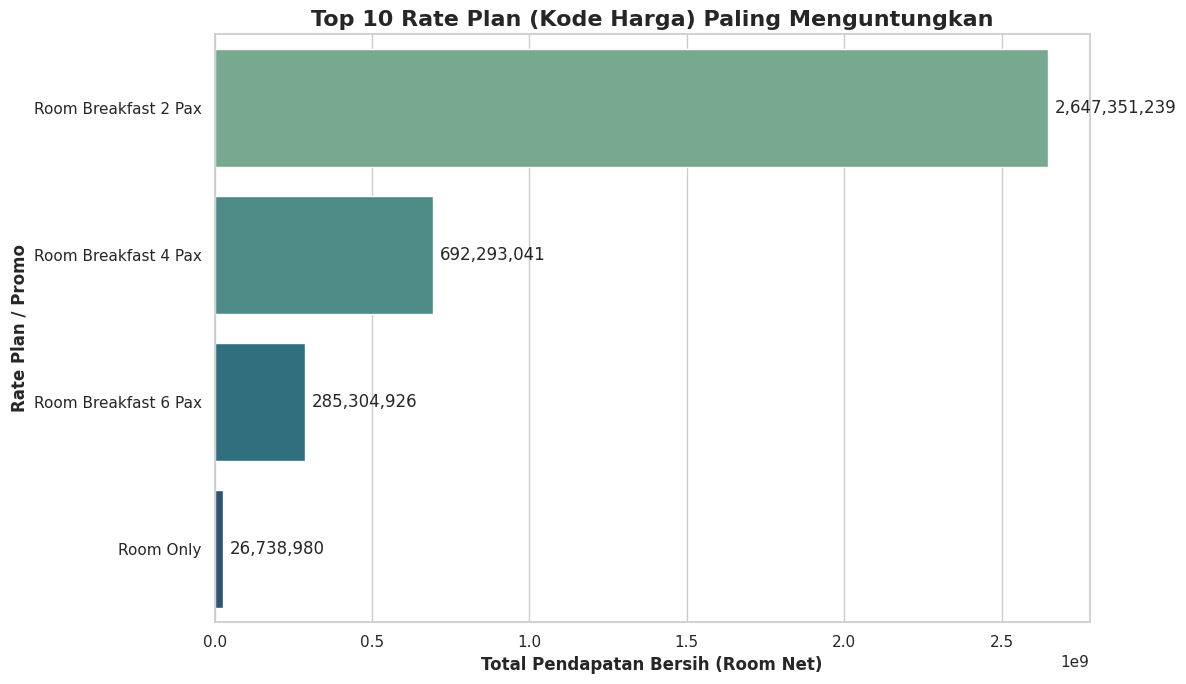

/tmp/ipykernel_14360/2435142551.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax8 = sns.barplot(x=top_vip['Total_Spend'], y=top_vip.index, palette="mako")


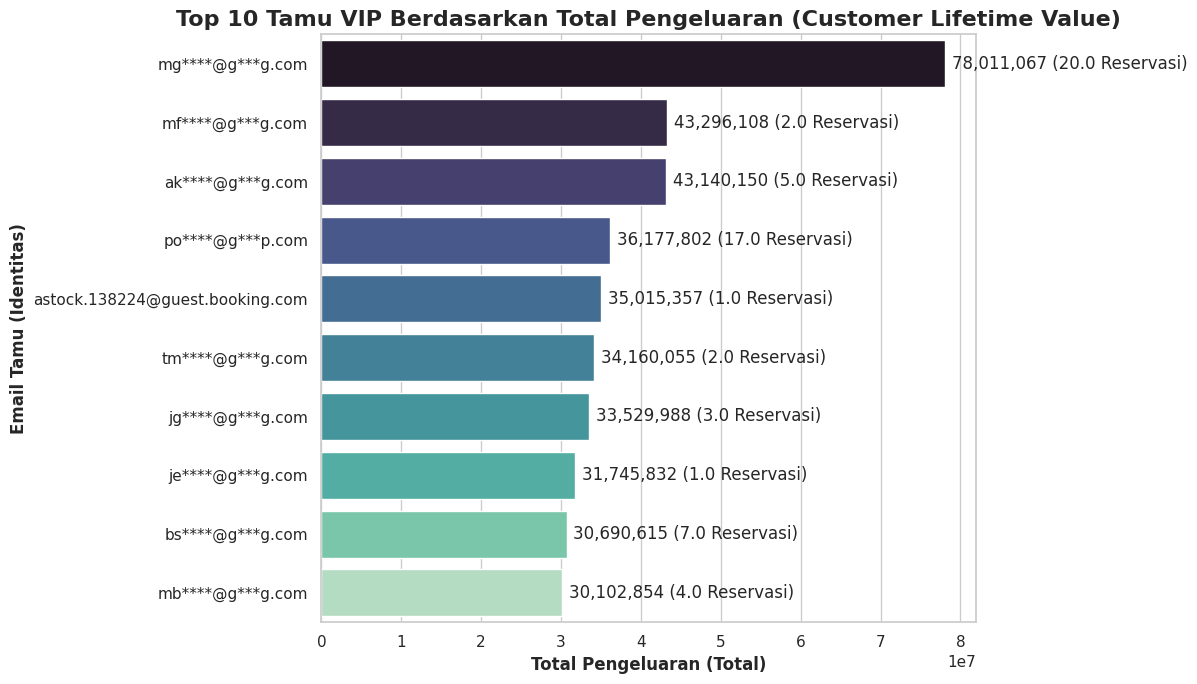

/tmp/ipykernel_14360/2435142551.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax9 = sns.barplot(x=room_utilization.values, y=room_utilization.index, palette="flare")


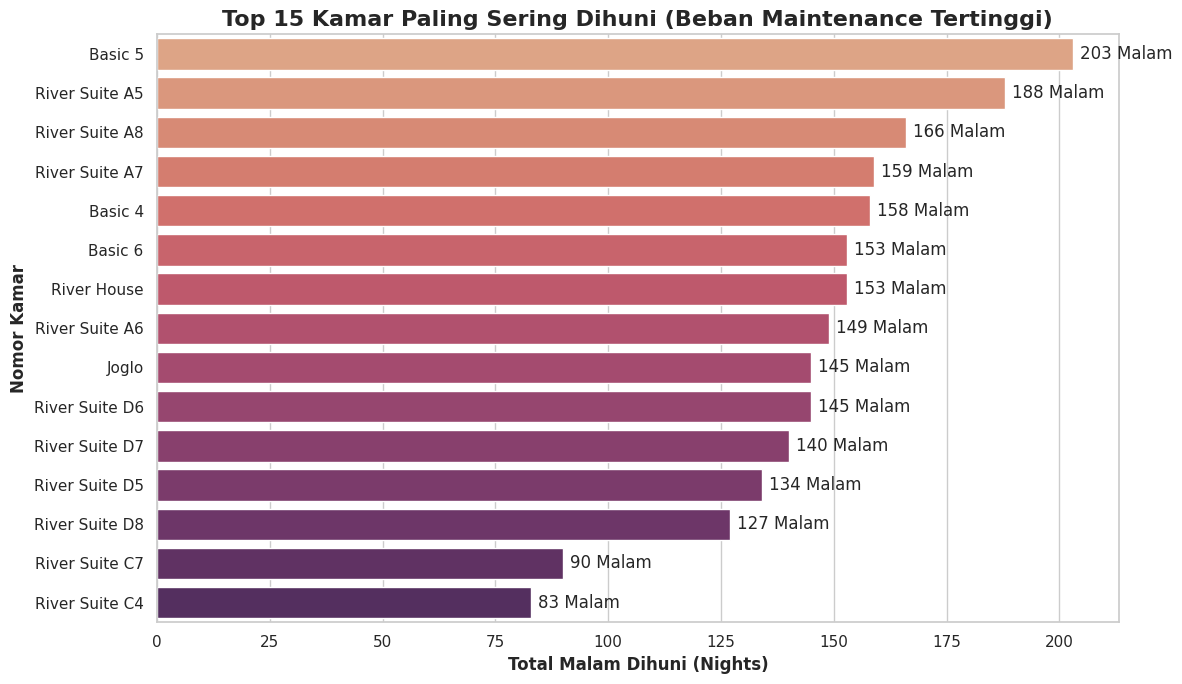

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema visual yang bersih dan profesional
sns.set_theme(style="whitegrid")
# Perbesar ukuran default agar cocok untuk slide presentasi
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# (Asumsi dataframe Anda sudah di-load ke dalam variabel 'df')
# df = pd.read_csv('data_reservasi.csv')

# =====================================================================
# 0. DATA CLEANING & FEATURE ENGINEERING (BAGIAN YANG TERLEWAT)
# =====================================================================
# Konversi kolom tanggal menjadi tipe datetime agar bisa dihitung selisihnya
df['Arrival'] = pd.to_datetime(df['Arrival'], errors='coerce')
df['Reservation Date'] = pd.to_datetime(df['Reservation Date'], errors='coerce')
df['Cancel Date'] = pd.to_datetime(df['Cancel Date'], errors='coerce')

# Membuat kolom Lead Time (Hari antara booking dan check-in)
df['Lead Time'] = (df['Arrival'] - df['Reservation Date']).dt.days

# =====================================================================
# 1. PRE-PROCESSING TAMBAHAN
# =====================================================================
# Membuat Kategori Lead Time (Bucketing) agar lebih mudah dipahami direksi
bins = [-1, 3, 14, 30, 90, 999]
labels = ['1. Last Minute (0-3 Hari)', '2. Short (4-14 Hari)', 
          '3. Advance (15-30 Hari)', '4. Early Bird (31-90 Hari)', '5. Very Early (>90 Hari)']
df['Lead Time Category'] = pd.cut(df['Lead Time'], bins=bins, labels=labels)

# Konsolidasi Nama Agent / OTA (Menghapus metode pembayaran)
df['Agent_Cleaned'] = df['Agent'].str.replace(r' Pay at Agent| Pay at Hotel', '', regex=True)
df['Agent_Cleaned'] = df['Agent_Cleaned'].str.strip()

# =====================================================================
# CHART 1: TREN VOLUME PEMESANAN (Kapan Tamu Biasanya Booking?)
# =====================================================================
plt.figure()
lead_time_vol = df['Lead Time Category'].value_counts().sort_index()
ax1 = sns.barplot(x=lead_time_vol.index, y=lead_time_vol.values, palette="Blues_d")
plt.title("Distribusi Volume Pemesanan Berdasarkan Jeda Waktu (Lead Time)", fontweight='bold')
plt.xlabel("Kategori Jeda Waktu Booking", fontweight='bold')
plt.ylabel("Jumlah Reservasi", fontweight='bold')

for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.0f'), 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 2: ANALISIS RISIKO PEMBATALAN (Di kategori mana Cancel tertinggi?)
# =====================================================================

# Persentase
cancel_df = df.groupby('Lead Time Category')['Status'].value_counts(normalize=True).unstack().fillna(0) * 100

# Jumlah (count)
cancel_count = df.groupby('Lead Time Category')['Status'].value_counts().unstack().fillna(0)

if 'CANCELLED' in cancel_df.columns:
    plt.figure()
    ax2 = sns.barplot(x=cancel_df.index, y=cancel_df['CANCELLED'], color='salmon')
    
    plt.title("Risiko Pembatalan (% Cancelled) Berdasarkan Lead Time", fontweight='bold')
    plt.xlabel("Kategori Jeda Waktu Booking", fontweight='bold')
    plt.ylabel("Persentase Batal (%)", fontweight='bold')
    
    for i, p in enumerate(ax2.patches):
        percent = p.get_height()
        count = cancel_count['CANCELLED'].iloc[i]
        
        ax2.annotate(f"{percent:.1f}%\n({int(count)})",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 12),
                     textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

# =====================================================================
# CHART 3: TOP 10 NEGARA BERDASARKAN PENDAPATAN (Market Profiling)
# =====================================================================
top_countries_rev = df.groupby('Country')['Room Net'].sum().sort_values(ascending=False).head(10)

plt.figure()
ax3 = sns.barplot(x=top_countries_rev.values, y=top_countries_rev.index, palette="viridis")
plt.title("Top 10 Negara Penyumbang Pendapatan Bersih (Room Net) Terbesar", fontweight='bold')
plt.xlabel("Total Pendapatan Bersih", fontweight='bold')
plt.ylabel("Negara", fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 4 (REVISI): KINERJA OTA / AGEN (Volume Reservasi)
# =====================================================================
top_agents = df['Agent_Cleaned'].value_counts().head(10)

plt.figure()
ax4 = sns.barplot(x=top_agents.values, y=top_agents.index, palette="magma")
plt.title("Top 10 Saluran Pemesanan (OTA/Agent) Paling Aktif", fontweight='bold')
plt.xlabel("Jumlah Reservasi", fontweight='bold')
plt.ylabel("Saluran Pemesanan", fontweight='bold')

for p in ax4.patches:
    ax4.annotate(f"{p.get_width():.0f}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 5: KOMPOSISI STATUS RESERVASI KESELURUHAN
# =====================================================================
status_counts = df['Status'].value_counts()

plt.figure(figsize=(10, 8))

def fmt_percentage(pct):
    return f'{pct:.1f}%' if pct > 2 else ''

wedges, texts, autotexts = plt.pie(
    status_counts.values, 
    autopct=fmt_percentage, 
    startangle=140, 
    colors=sns.color_palette("pastel")[0:len(status_counts)],
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)

total_reservasi = status_counts.sum()
legend_labels = [f'{status} ({count/total_reservasi*100:.1f}%)' 
                 for status, count in zip(status_counts.index, status_counts.values)]

plt.legend(
    wedges, 
    legend_labels,
    title="Detail Status Reservasi",
    title_fontsize=12,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Komposisi Status Reservasi Keseluruhan", fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema visual eksekutif
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# =====================================================================
# FEATURE ENGINEERING TAMBAHAN
# =====================================================================
# Menggabungkan Extra Charge dan Pos menjadi Total Ancillary Revenue
df['Total Ancillary'] = df['Extra Charge'] + df['Pos']

# =====================================================================
# CHART 6 (REVISI): ANALISIS ANCILLARY REVENUE (F&B, Spa, dll)
# =====================================================================
# Memastikan kolom Total Ancillary sudah dibuat (jika belum)
if 'Total Ancillary' not in df.columns:
    df['Total Ancillary'] = df['Extra Charge'] + df['Pos']

# Mencari OTA/Agent (yang sudah dibersihkan) mana yang tamunya paling banyak jajan
ancillary_perf = df.groupby('Agent_Cleaned')['Total Ancillary'].sum().sort_values(ascending=False).head(10)

plt.figure()
ax6 = sns.barplot(x=ancillary_perf.values, y=ancillary_perf.index, palette="rocket")
plt.title("Top 10 Agent Penyumbang Pendapatan Ekstra Terbesar", fontweight='bold')
plt.xlabel("Total Ancillary Revenue", fontweight='bold')
plt.ylabel("Saluran Pemesanan (Agent)", fontweight='bold')

# Menambahkan format mata uang/angka di ujung bar
for p in ax6.patches:
    ax6.annotate(f"{p.get_width():,.0f}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')

plt.tight_layout()
plt.show()
# =====================================================================
# CHART 7: EFEKTIVITAS RATE PLAN / PROMO (Yield Management)
# =====================================================================
# Melihat kode harga (Rates) apa yang paling menghasilkan Room Net tertinggi
rates_perf = df.groupby('Rates')['Room Net'].sum().sort_values(ascending=False).head(10)

plt.figure()
ax7 = sns.barplot(x=rates_perf.values, y=rates_perf.index, palette="crest")
plt.title("Top 10 Rate Plan (Kode Harga) Paling Menguntungkan", fontweight='bold')
plt.xlabel("Total Pendapatan Bersih (Room Net)", fontweight='bold')
plt.ylabel("Rate Plan / Promo", fontweight='bold')

for p in ax7.patches:
    ax7.annotate(f"{p.get_width():,.0f}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 8: ANALISIS LOYALITAS TAMU (Top VIP Guests)
# =====================================================================
# Menghapus data email yang kosong (karena kita tidak bisa melacak tamu tanpa identitas)
df_guests = df.dropna(subset=['Guest Email'])

# Mencari tamu dengan Total pengeluaran (kamar + ekstra) tertinggi
top_vip = df_guests.groupby('Guest Email').agg(
    Total_Spend=('Total', 'sum'),
    Total_Visits=('Folio', 'count') # Menghitung berapa kali mereka menginap
).sort_values('Total_Spend', ascending=False).head(10)

plt.figure()
ax8 = sns.barplot(x=top_vip['Total_Spend'], y=top_vip.index, palette="mako")
plt.title("Top 10 Tamu VIP Berdasarkan Total Pengeluaran (Customer Lifetime Value)", fontweight='bold')
plt.xlabel("Total Pengeluaran (Total)", fontweight='bold')
plt.ylabel("Email Tamu (Identitas)", fontweight='bold')

# Menampilkan total visit di sebelah nominal uang agar direksi tahu apakah ini tamu long-stay atau repeat guest
for i, p in enumerate(ax8.patches):
    visit_count = top_vip.iloc[i]['Total_Visits']
    ax8.annotate(f"{p.get_width():,.0f} ({visit_count} Reservasi)", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 9: UTILISASI FISIK KAMAR (Analisa Beban Operasional / Wear & Tear)
# =====================================================================
# Hanya menganalisa reservasi yang sudah benar-benar check-out (bukan yang batal/no show)
df_checkout = df[df['Status'].str.upper() == 'CHECK_OUT']

# Menghitung total malam (Nights) masing-masing nomor kamar digunakan
room_utilization = df_checkout.groupby('Room')['Nights'].sum().sort_values(ascending=False).head(15)

plt.figure()
ax9 = sns.barplot(x=room_utilization.values, y=room_utilization.index, palette="flare")
plt.title("Top 15 Kamar Paling Sering Dihuni (Beban Maintenance Tertinggi)", fontweight='bold')
plt.xlabel("Total Malam Dihuni (Nights)", fontweight='bold')
plt.ylabel("Nomor Kamar", fontweight='bold')

for p in ax9.patches:
    ax9.annotate(f"{p.get_width():.0f} Malam", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()


# 2025

/tmp/ipykernel_14360/4156865730.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=lead_time_vol.index, y=lead_time_vol.values, palette="Blues_d")


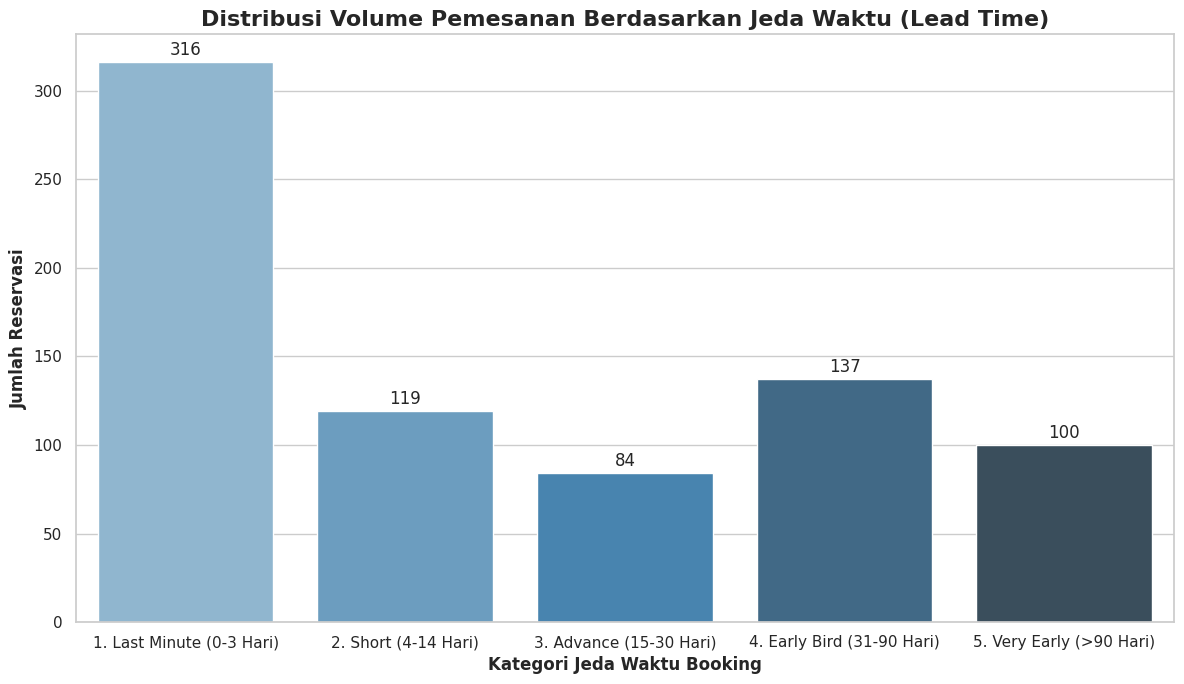

/tmp/ipykernel_14360/4156865730.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_df_2025 = df_2025.groupby('Lead Time Category')['Status'].value_counts(normalize=True).unstack().fillna(0) * 100


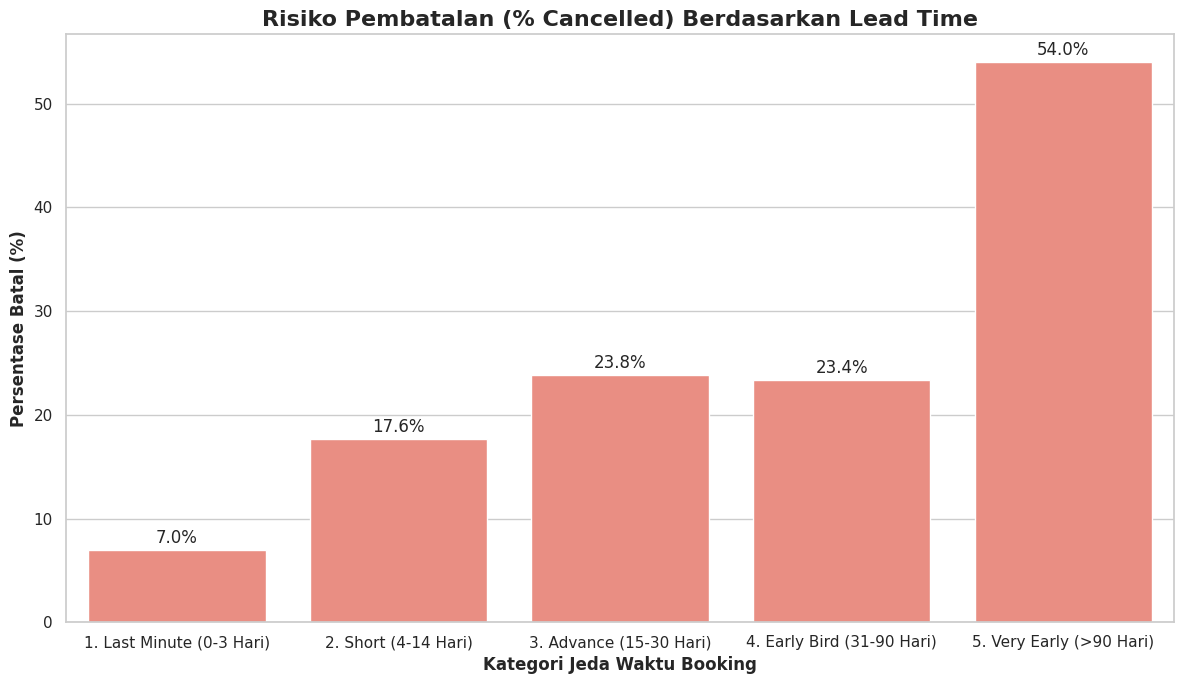

/tmp/ipykernel_14360/4156865730.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(x=top_countries_rev.values, y=top_countries_rev.index, palette="viridis")


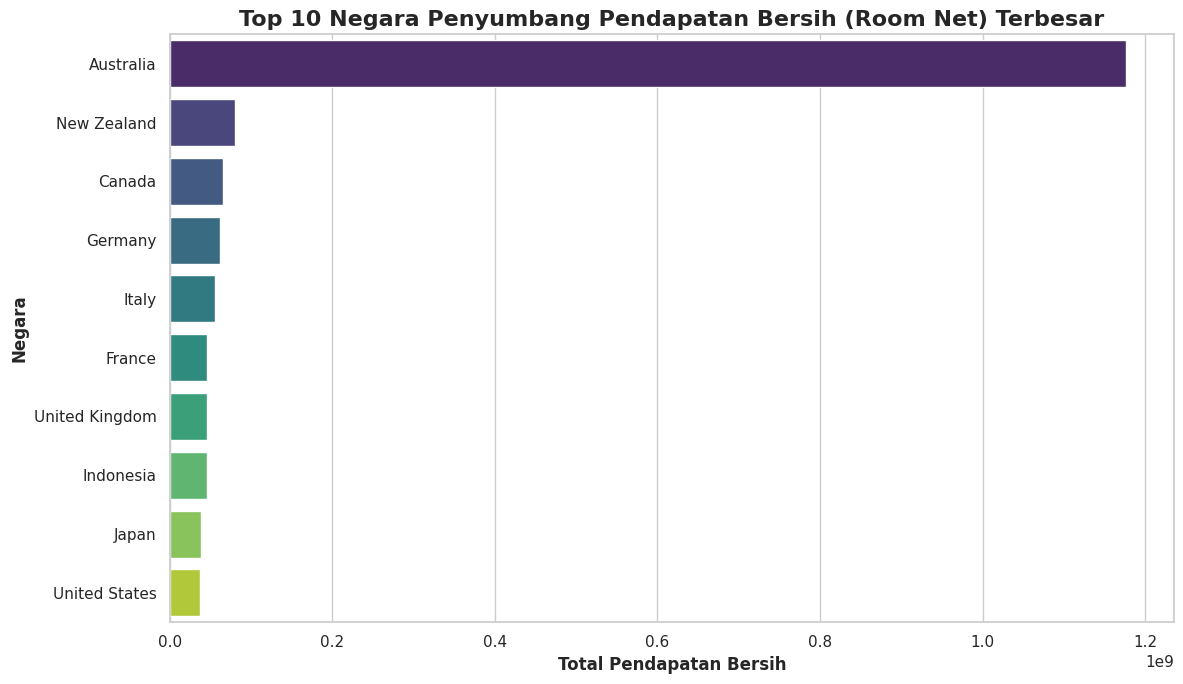

/tmp/ipykernel_14360/4156865730.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(x=top_agents.values, y=top_agents.index, palette="magma")


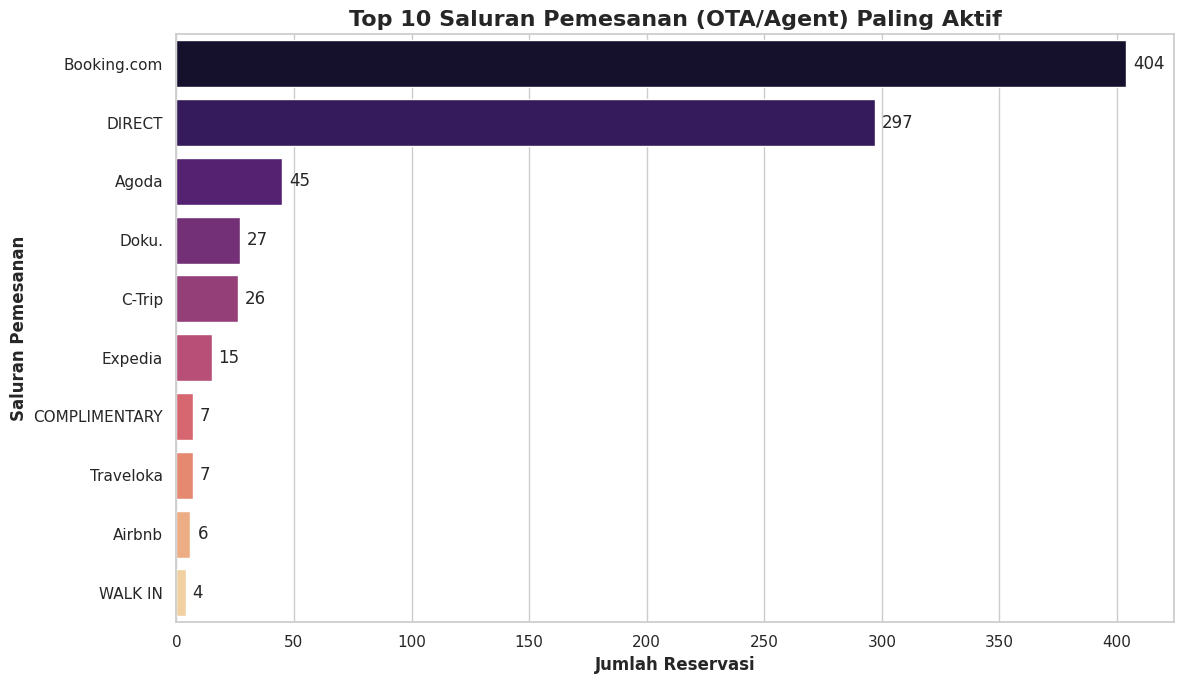

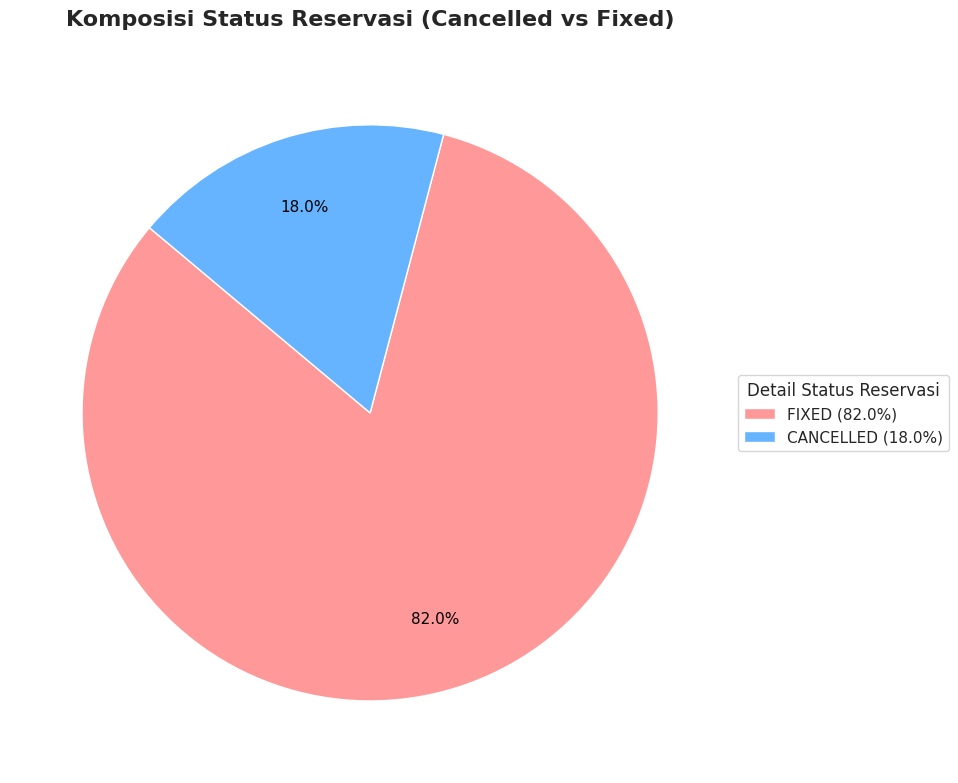

/tmp/ipykernel_14360/4156865730.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax6 = sns.barplot(x=ancillary_perf.values, y=ancillary_perf.index, palette="rocket")


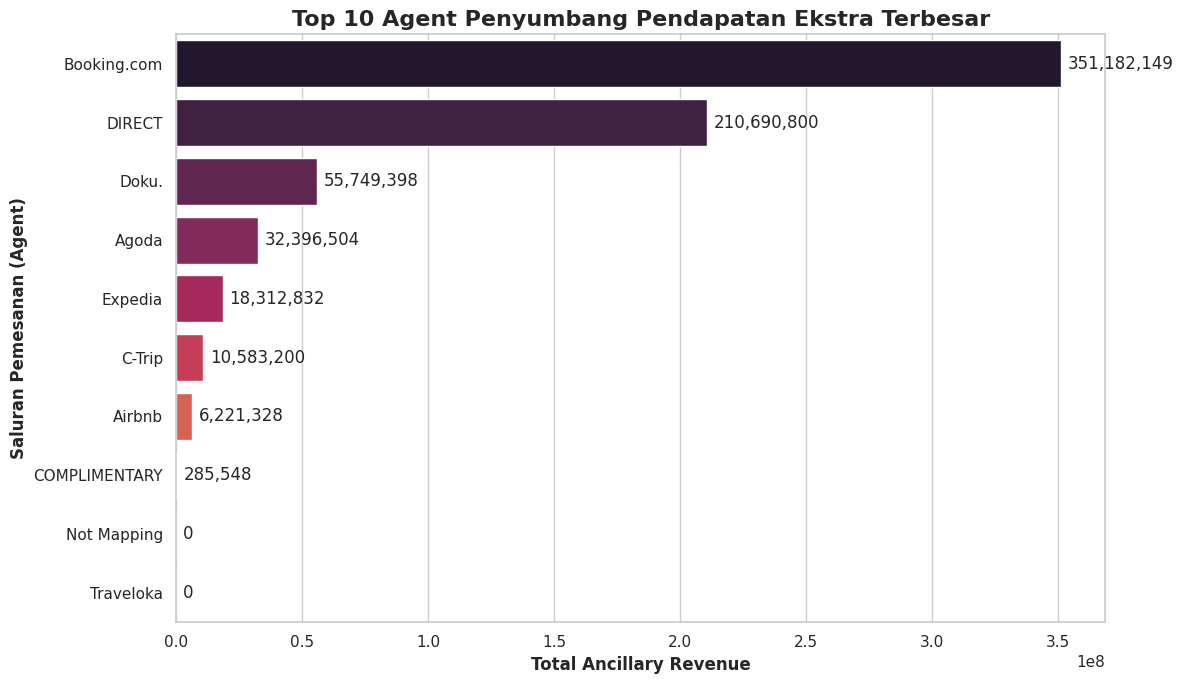

/tmp/ipykernel_14360/4156865730.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax7 = sns.barplot(x=rates_perf.values, y=rates_perf.index, palette="crest")


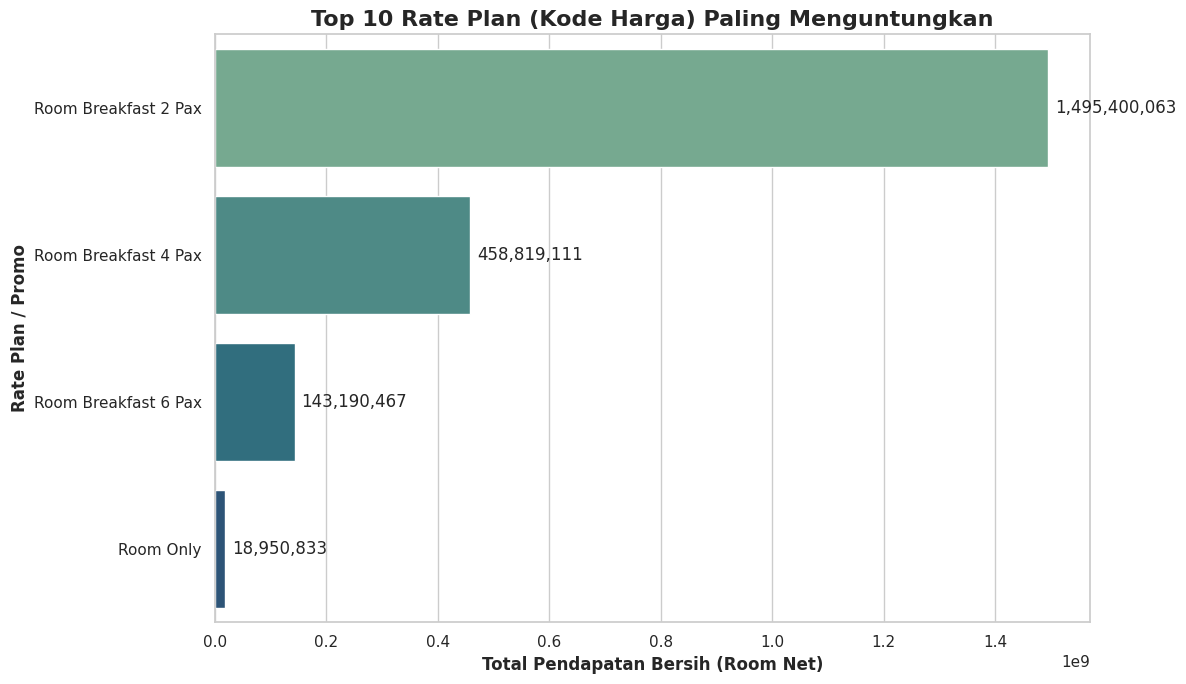

/tmp/ipykernel_14360/4156865730.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax8 = sns.barplot(x=top_vip['Total_Spend'], y=top_vip.index, palette="mako")


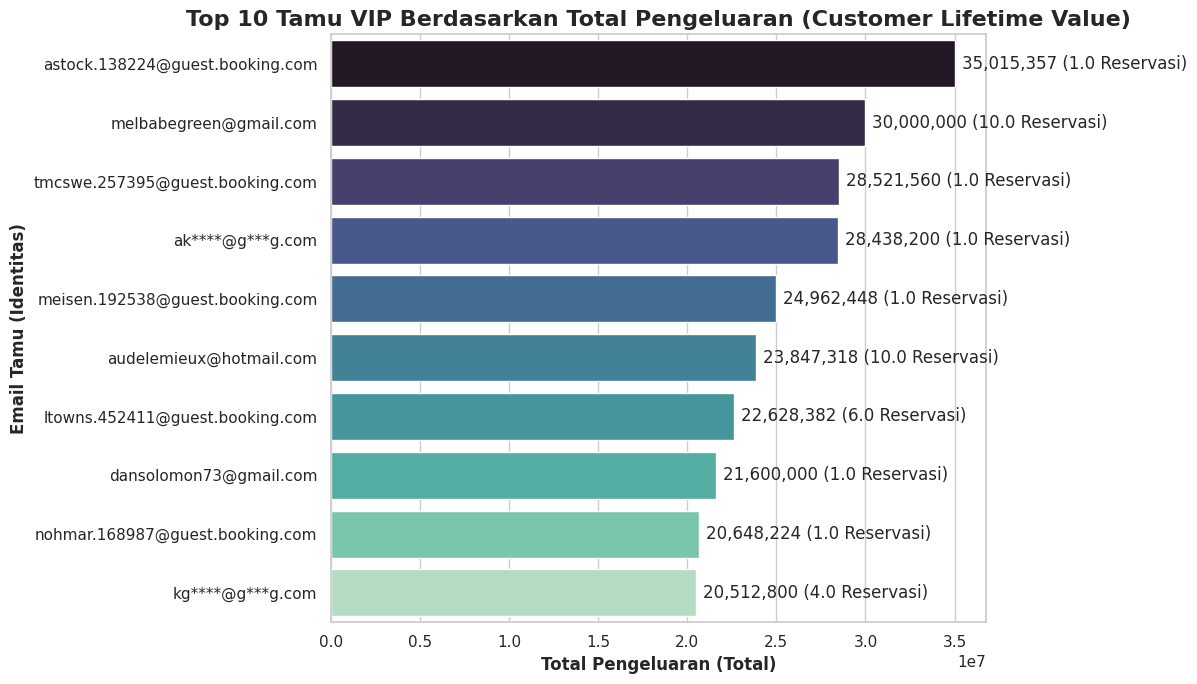

/tmp/ipykernel_14360/4156865730.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax9 = sns.barplot(x=room_utilization.values, y=room_utilization.index, palette="flare")


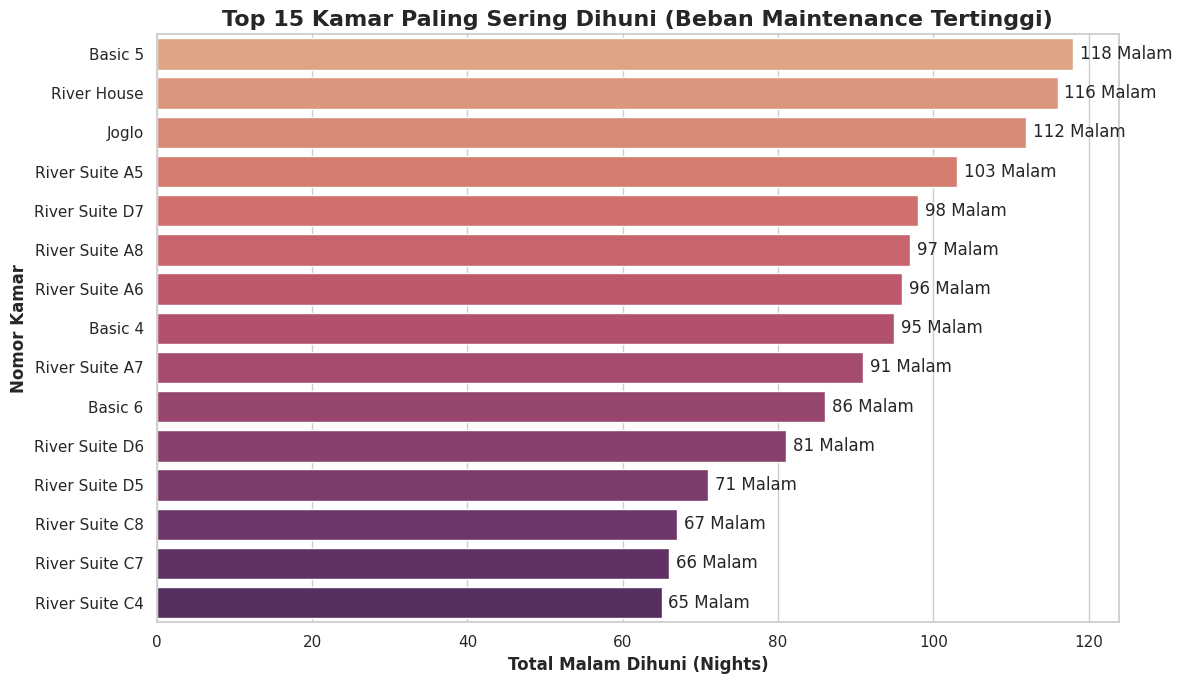

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema visual yang bersih dan profesional
sns.set_theme(style="whitegrid")
# Perbesar ukuran default agar cocok untuk slide presentasi
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# (Asumsi dataframe Anda sudah di-load ke dalam variabel 'df_2025')
# df_2025 = pd.read_csv('data_reservasi.csv')

# =====================================================================
# 0. DATA CLEANING & FEATURE ENGINEERING (BAGIAN YANG TERLEWAT)
# =====================================================================
# Konversi kolom tanggal menjadi tipe datetime agar bisa dihitung selisihnya
df_2025['Arrival'] = pd.to_datetime(df_2025['Arrival'], errors='coerce')
df_2025['Reservation Date'] = pd.to_datetime(df_2025['Reservation Date'], errors='coerce')
df_2025['Cancel Date'] = pd.to_datetime(df_2025['Cancel Date'], errors='coerce')

# Membuat kolom Lead Time (Hari antara booking dan check-in)
df_2025['Lead Time'] = (df_2025['Arrival'] - df_2025['Reservation Date']).dt.days

# =====================================================================
# 1. PRE-PROCESSING TAMBAHAN
# =====================================================================
# Membuat Kategori Lead Time (Bucketing) agar lebih mudah dipahami direksi
bins = [-1, 3, 14, 30, 90, 999]
labels = ['1. Last Minute (0-3 Hari)', '2. Short (4-14 Hari)', 
          '3. Advance (15-30 Hari)', '4. Early Bird (31-90 Hari)', '5. Very Early (>90 Hari)']
df_2025['Lead Time Category'] = pd.cut(df_2025['Lead Time'], bins=bins, labels=labels)

# Konsolidasi Nama Agent / OTA (Menghapus metode pembayaran)
df_2025['Agent_Cleaned'] = df_2025['Agent'].str.replace(r' Pay at Agent| Pay at Hotel', '', regex=True)
df_2025['Agent_Cleaned'] = df_2025['Agent_Cleaned'].str.strip()

# =====================================================================
# CHART 1: TREN VOLUME PEMESANAN (Kapan Tamu Biasanya Booking?)
# =====================================================================
plt.figure()
lead_time_vol = df_2025['Lead Time Category'].value_counts().sort_index()
ax1 = sns.barplot(x=lead_time_vol.index, y=lead_time_vol.values, palette="Blues_d")
plt.title("Distribusi Volume Pemesanan Berdasarkan Jeda Waktu (Lead Time)", fontweight='bold')
plt.xlabel("Kategori Jeda Waktu Booking", fontweight='bold')
plt.ylabel("Jumlah Reservasi", fontweight='bold')

for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.0f'), 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 2: ANALISIS RISIKO PEMBATALAN (Di kategori mana Cancel tertinggi?)
# =====================================================================
cancel_df_2025 = df_2025.groupby('Lead Time Category')['Status'].value_counts(normalize=True).unstack().fillna(0) * 100
if 'CANCELLED' in cancel_df_2025.columns:
    plt.figure()
    ax2 = sns.barplot(x=cancel_df_2025.index, y=cancel_df_2025['CANCELLED'], color='salmon')
    plt.title("Risiko Pembatalan (% Cancelled) Berdasarkan Lead Time", fontweight='bold')
    plt.xlabel("Kategori Jeda Waktu Booking", fontweight='bold')
    plt.ylabel("Persentase Batal (%)", fontweight='bold')
    
    for p in ax2.patches:
        ax2.annotate(f"{p.get_height():.1f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
    plt.tight_layout()
    plt.show()

# =====================================================================
# CHART 3: TOP 10 NEGARA BERDASARKAN PENDAPATAN (Market Profiling)
# =====================================================================
top_countries_rev = df_2025.groupby('Country')['Room Net'].sum().sort_values(ascending=False).head(10)

plt.figure()
ax3 = sns.barplot(x=top_countries_rev.values, y=top_countries_rev.index, palette="viridis")
plt.title("Top 10 Negara Penyumbang Pendapatan Bersih (Room Net) Terbesar", fontweight='bold')
plt.xlabel("Total Pendapatan Bersih", fontweight='bold')
plt.ylabel("Negara", fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 4 (REVISI): KINERJA OTA / AGEN (Volume Reservasi)
# =====================================================================
top_agents = df_2025['Agent_Cleaned'].value_counts().head(10)

plt.figure()
ax4 = sns.barplot(x=top_agents.values, y=top_agents.index, palette="magma")
plt.title("Top 10 Saluran Pemesanan (OTA/Agent) Paling Aktif", fontweight='bold')
plt.xlabel("Jumlah Reservasi", fontweight='bold')
plt.ylabel("Saluran Pemesanan", fontweight='bold')

for p in ax4.patches:
    ax4.annotate(f"{p.get_width():.0f}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 5: KOMPOSISI STATUS RESERVASI (CANCELLED vs FIXED)
# =====================================================================

# Mapping status
df_2025['Status_Grouped'] = df_2025['Status'].apply(
    lambda x: 'CANCELLED' if x == 'CANCELLED' else 'FIXED'
)

status_counts = df_2025['Status_Grouped'].value_counts()

plt.figure(figsize=(10, 8))

def fmt_percentage(pct):
    return f'{pct:.1f}%' if pct > 2 else ''

wedges, texts, autotexts = plt.pie(
    status_counts.values, 
    autopct=fmt_percentage, 
    startangle=140, 
    colors=['#ff9999', '#66b3ff'],  # merah = cancel, biru = fixed
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)

total_reservasi = status_counts.sum()
legend_labels = [f'{status} ({count/total_reservasi*100:.1f}%)' 
                 for status, count in zip(status_counts.index, status_counts.values)]

plt.legend(
    wedges, 
    legend_labels,
    title="Detail Status Reservasi",
    title_fontsize=12,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Komposisi Status Reservasi (Cancelled vs Fixed)", fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema visual eksekutif
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# =====================================================================
# FEATURE ENGINEERING TAMBAHAN
# =====================================================================
# Menggabungkan Extra Charge dan Pos menjadi Total Ancillary Revenue
df_2025['Total Ancillary'] = df_2025['Extra Charge'] + df_2025['Pos']

# =====================================================================
# CHART 6 (REVISI): ANALISIS ANCILLARY REVENUE (F&B, Spa, dll)
# =====================================================================
# Memastikan kolom Total Ancillary sudah dibuat (jika belum)
if 'Total Ancillary' not in df_2025.columns:
    df_2025['Total Ancillary'] = df_2025['Extra Charge'] + df_2025['Pos']

# Mencari OTA/Agent (yang sudah dibersihkan) mana yang tamunya paling banyak jajan
ancillary_perf = df_2025.groupby('Agent_Cleaned')['Total Ancillary'].sum().sort_values(ascending=False).head(10)

plt.figure()
ax6 = sns.barplot(x=ancillary_perf.values, y=ancillary_perf.index, palette="rocket")
plt.title("Top 10 Agent Penyumbang Pendapatan Ekstra Terbesar", fontweight='bold')
plt.xlabel("Total Ancillary Revenue", fontweight='bold')
plt.ylabel("Saluran Pemesanan (Agent)", fontweight='bold')

# Menambahkan format mata uang/angka di ujung bar
for p in ax6.patches:
    ax6.annotate(f"{p.get_width():,.0f}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')

plt.tight_layout()
plt.show()
# =====================================================================
# CHART 7: EFEKTIVITAS RATE PLAN / PROMO (Yield Management)
# =====================================================================
# Melihat kode harga (Rates) apa yang paling menghasilkan Room Net tertinggi
rates_perf = df_2025.groupby('Rates')['Room Net'].sum().sort_values(ascending=False).head(10)

plt.figure()
ax7 = sns.barplot(x=rates_perf.values, y=rates_perf.index, palette="crest")
plt.title("Top 10 Rate Plan (Kode Harga) Paling Menguntungkan", fontweight='bold')
plt.xlabel("Total Pendapatan Bersih (Room Net)", fontweight='bold')
plt.ylabel("Rate Plan / Promo", fontweight='bold')

for p in ax7.patches:
    ax7.annotate(f"{p.get_width():,.0f}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 8: ANALISIS LOYALITAS TAMU (Top VIP Guests)
# =====================================================================
# Menghapus data email yang kosong (karena kita tidak bisa melacak tamu tanpa identitas)
df_2025_guests = df_2025.dropna(subset=['Guest Email'])

# Mencari tamu dengan Total pengeluaran (kamar + ekstra) tertinggi
top_vip = df_2025_guests.groupby('Guest Email').agg(
    Total_Spend=('Total', 'sum'),
    Total_Visits=('Folio', 'count') # Menghitung berapa kali mereka menginap
).sort_values('Total_Spend', ascending=False).head(10)

plt.figure()
ax8 = sns.barplot(x=top_vip['Total_Spend'], y=top_vip.index, palette="mako")
plt.title("Top 10 Tamu VIP Berdasarkan Total Pengeluaran (Customer Lifetime Value)", fontweight='bold')
plt.xlabel("Total Pengeluaran (Total)", fontweight='bold')
plt.ylabel("Email Tamu (Identitas)", fontweight='bold')

# Menampilkan total visit di sebelah nominal uang agar direksi tahu apakah ini tamu long-stay atau repeat guest
for i, p in enumerate(ax8.patches):
    visit_count = top_vip.iloc[i]['Total_Visits']
    ax8.annotate(f"{p.get_width():,.0f} ({visit_count} Reservasi)", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 9: UTILISASI FISIK KAMAR (Analisa Beban Operasional / Wear & Tear)
# =====================================================================
# Hanya menganalisa reservasi yang sudah benar-benar check-out (bukan yang batal/no show)
df_2025_checkout = df_2025[df_2025['Status'].str.upper() == 'CHECK_OUT']

# Menghitung total malam (Nights) masing-masing nomor kamar digunakan
room_utilization = df_2025_checkout.groupby('Room')['Nights'].sum().sort_values(ascending=False).head(15)

plt.figure()
ax9 = sns.barplot(x=room_utilization.values, y=room_utilization.index, palette="flare")
plt.title("Top 15 Kamar Paling Sering Dihuni (Beban Maintenance Tertinggi)", fontweight='bold')
plt.xlabel("Total Malam Dihuni (Nights)", fontweight='bold')
plt.ylabel("Nomor Kamar", fontweight='bold')

for p in ax9.patches:
    ax9.annotate(f"{p.get_width():.0f} Malam", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()


# 2026

/tmp/ipykernel_14360/205484900.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=lead_time_vol.index, y=lead_time_vol.values, palette="Blues_d")


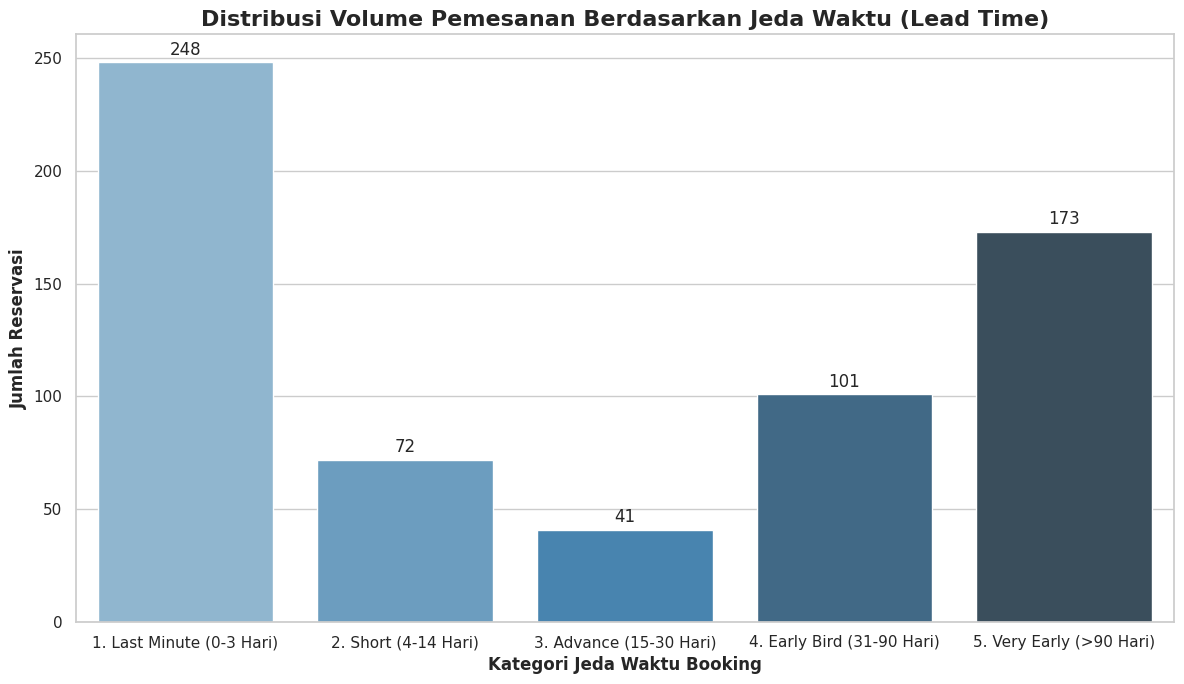

/tmp/ipykernel_14360/205484900.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_df_2026 = df_2026.groupby('Lead Time Category')['Status'].value_counts(normalize=True).unstack().fillna(0) * 100


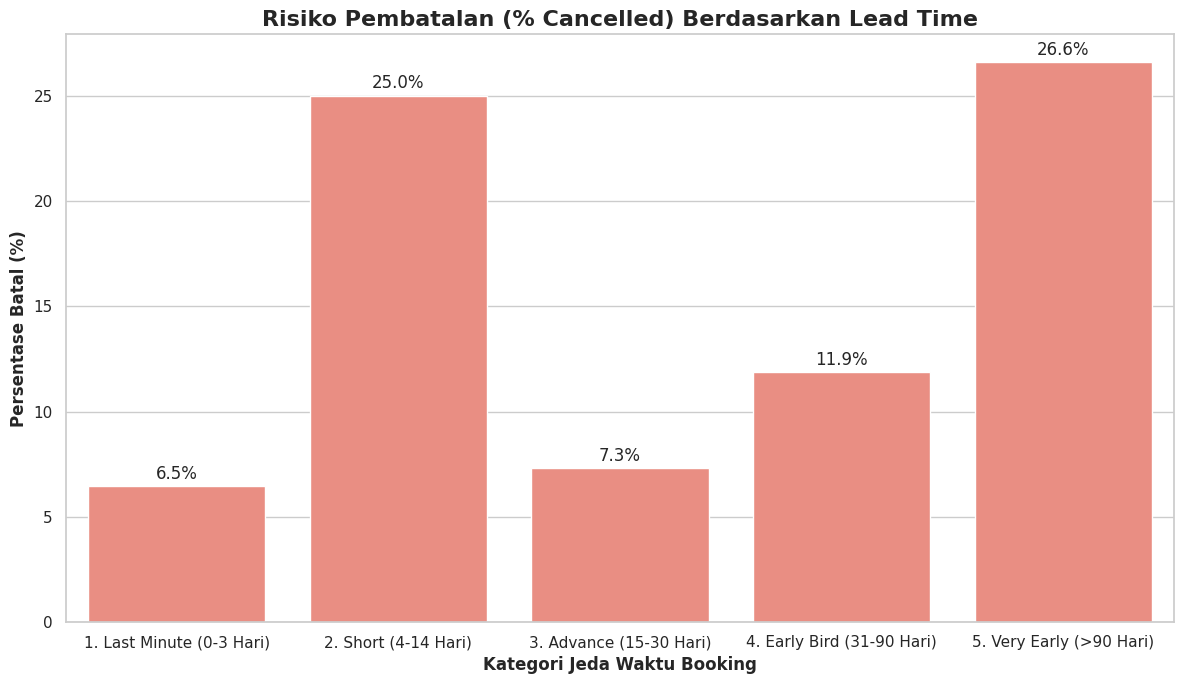

/tmp/ipykernel_14360/205484900.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(x=top_countries_rev.values, y=top_countries_rev.index, palette="viridis")


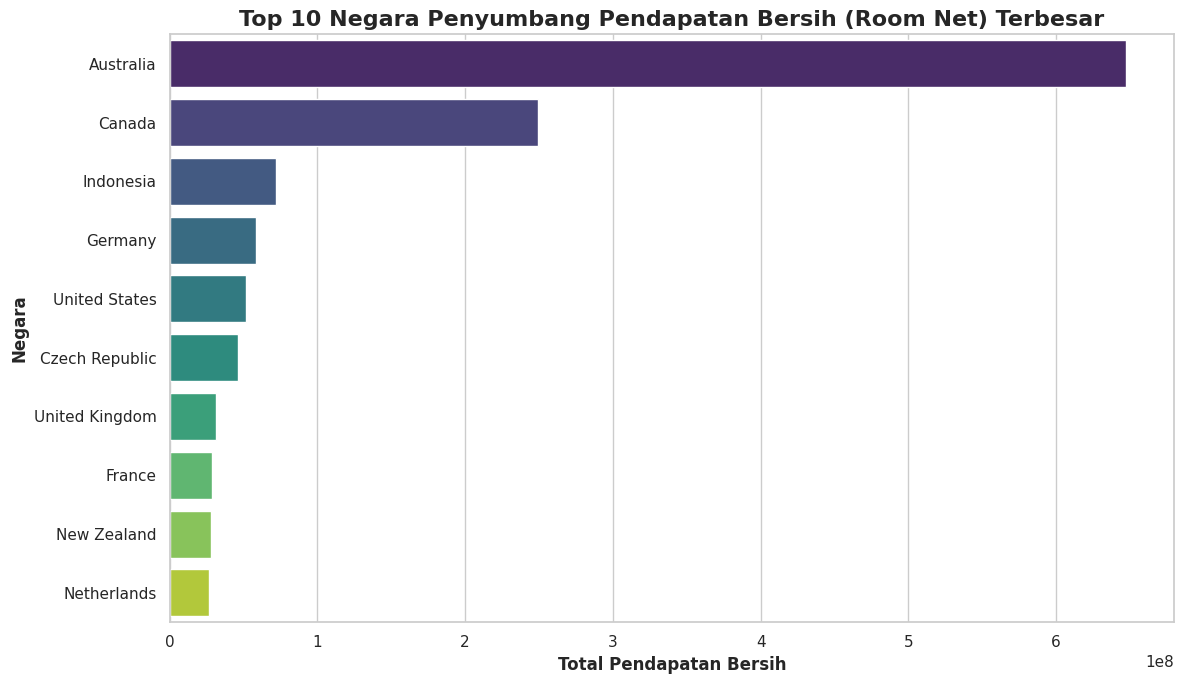

/tmp/ipykernel_14360/205484900.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(x=top_agents.values, y=top_agents.index, palette="magma")


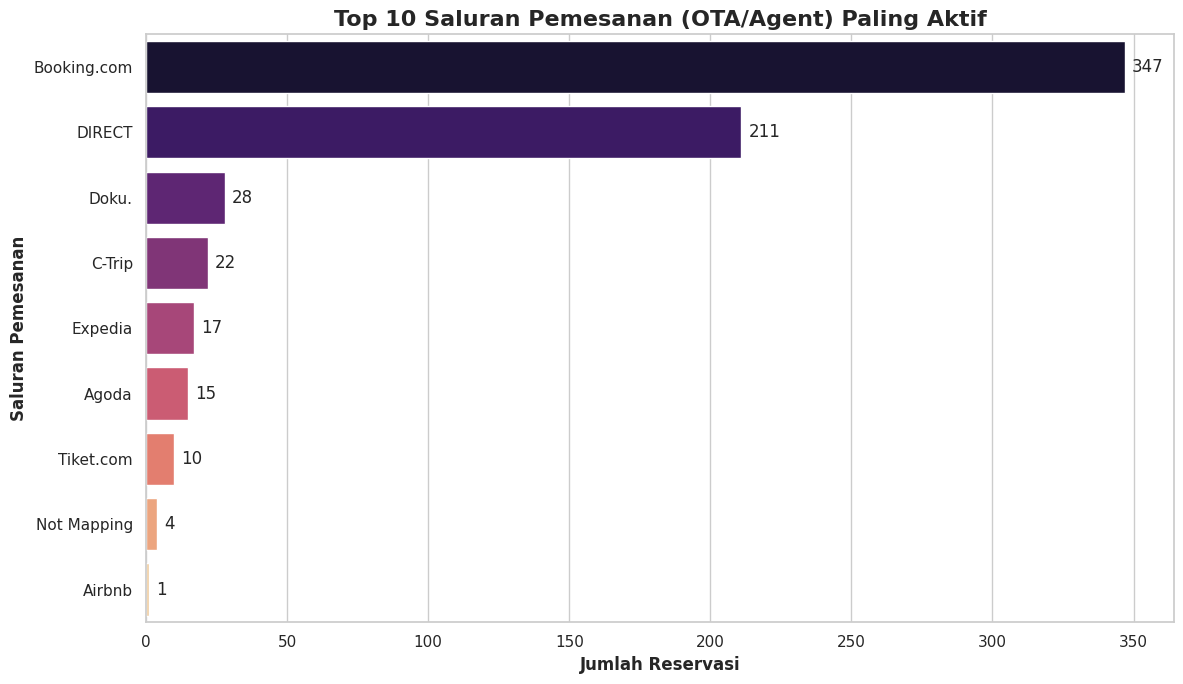

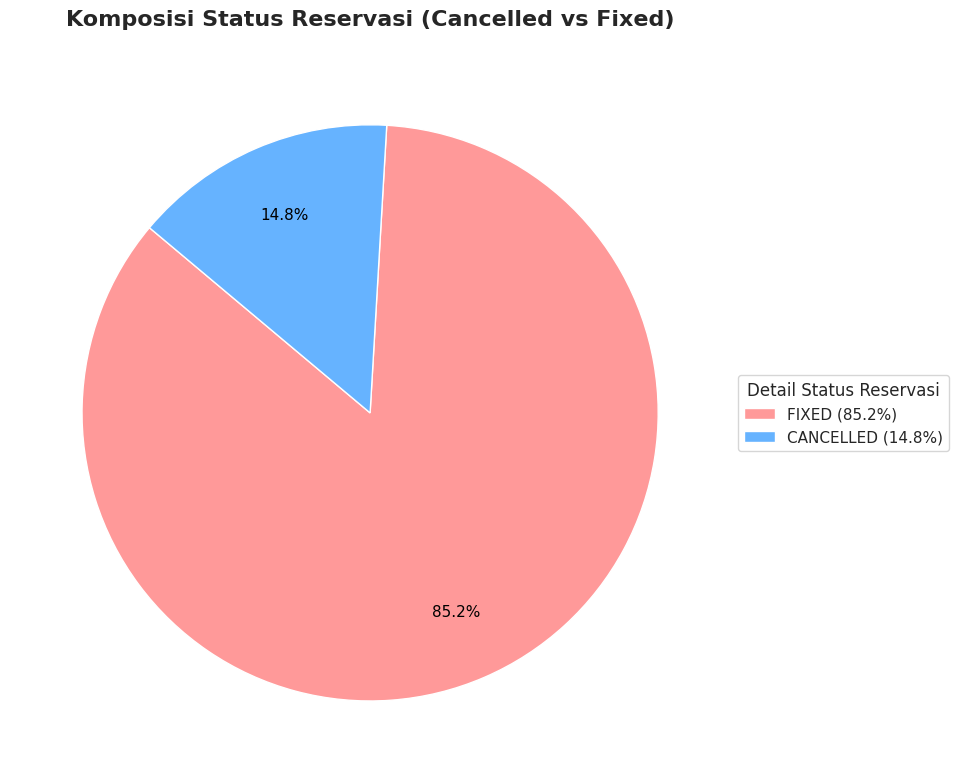

/tmp/ipykernel_14360/205484900.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax6 = sns.barplot(x=ancillary_perf.values, y=ancillary_perf.index, palette="rocket")


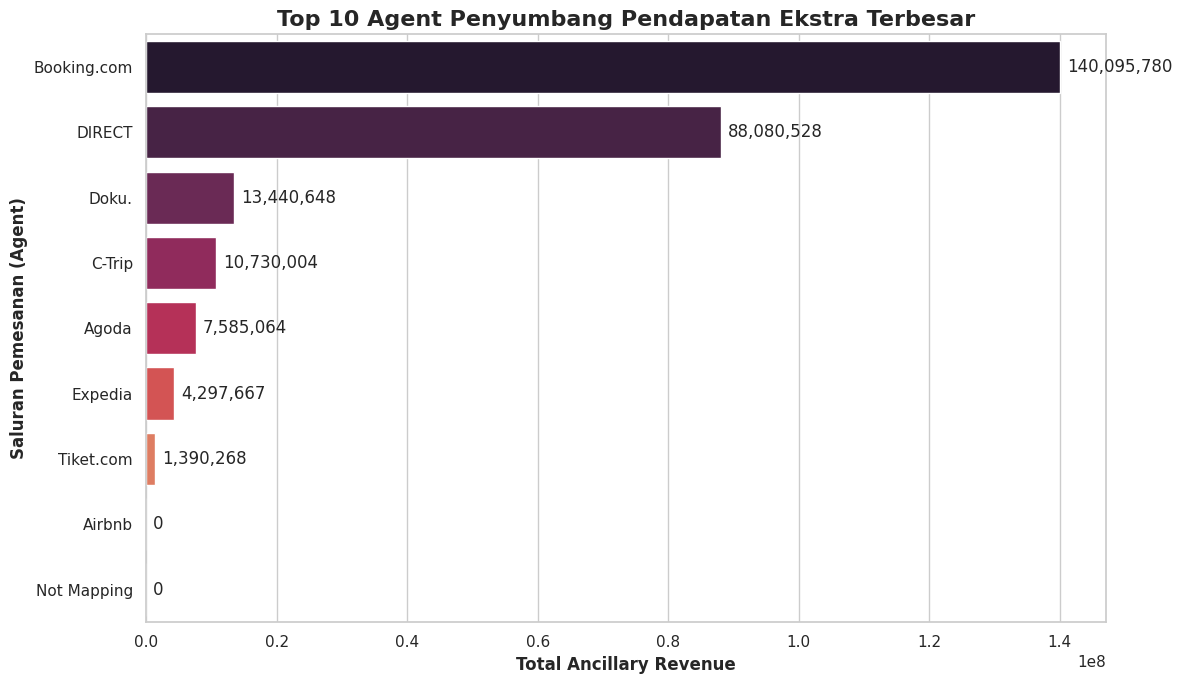

/tmp/ipykernel_14360/205484900.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax7 = sns.barplot(x=rates_perf.values, y=rates_perf.index, palette="crest")


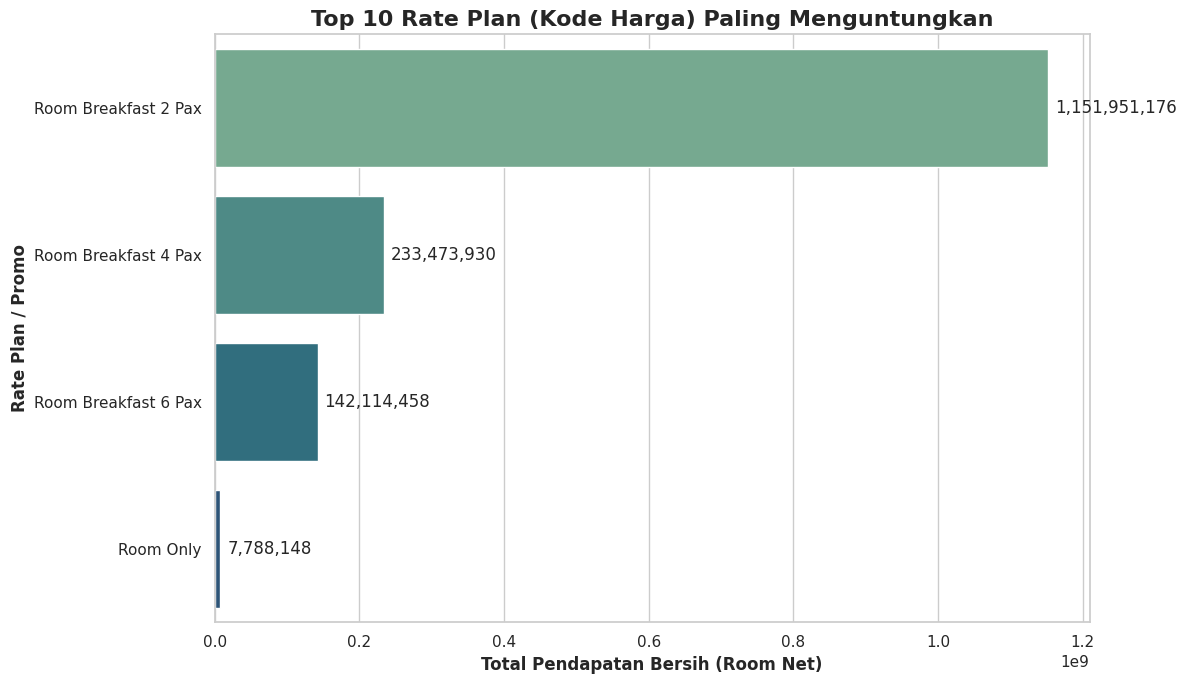

/tmp/ipykernel_14360/205484900.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax8 = sns.barplot(x=top_vip['Total_Spend'], y=top_vip.index, palette="mako")


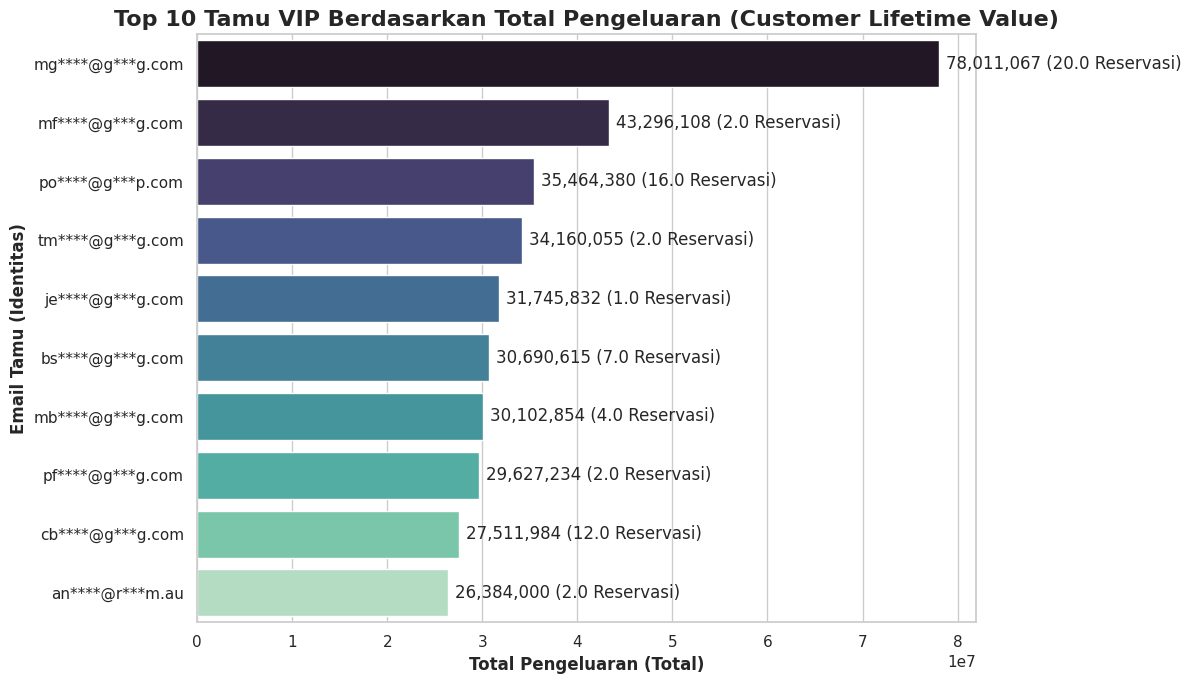

/tmp/ipykernel_14360/205484900.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax9 = sns.barplot(x=room_utilization.values, y=room_utilization.index, palette="flare")


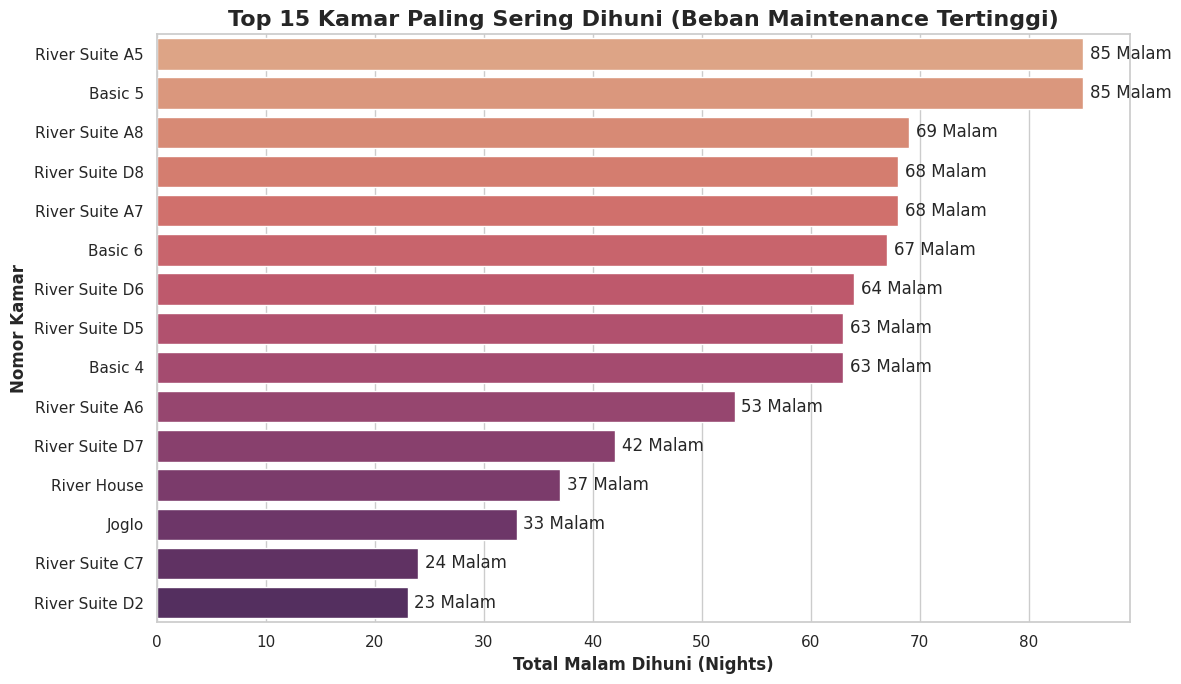

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema visual yang bersih dan profesional
sns.set_theme(style="whitegrid")
# Perbesar ukuran default agar cocok untuk slide presentasi
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# (Asumsi dataframe Anda sudah di-load ke dalam variabel 'df_2026')
# df_2026 = pd.read_csv('data_reservasi.csv')

# =====================================================================
# 0. DATA CLEANING & FEATURE ENGINEERING (BAGIAN YANG TERLEWAT)
# =====================================================================
# Konversi kolom tanggal menjadi tipe datetime agar bisa dihitung selisihnya
df_2026['Arrival'] = pd.to_datetime(df_2026['Arrival'], errors='coerce')
df_2026['Reservation Date'] = pd.to_datetime(df_2026['Reservation Date'], errors='coerce')
df_2026['Cancel Date'] = pd.to_datetime(df_2026['Cancel Date'], errors='coerce')

# Membuat kolom Lead Time (Hari antara booking dan check-in)
df_2026['Lead Time'] = (df_2026['Arrival'] - df_2026['Reservation Date']).dt.days

# =====================================================================
# 1. PRE-PROCESSING TAMBAHAN
# =====================================================================
# Membuat Kategori Lead Time (Bucketing) agar lebih mudah dipahami direksi
bins = [-1, 3, 14, 30, 90, 999]
labels = ['1. Last Minute (0-3 Hari)', '2. Short (4-14 Hari)', 
          '3. Advance (15-30 Hari)', '4. Early Bird (31-90 Hari)', '5. Very Early (>90 Hari)']
df_2026['Lead Time Category'] = pd.cut(df_2026['Lead Time'], bins=bins, labels=labels)

# Konsolidasi Nama Agent / OTA (Menghapus metode pembayaran)
df_2026['Agent_Cleaned'] = df_2026['Agent'].str.replace(r' Pay at Agent| Pay at Hotel', '', regex=True)
df_2026['Agent_Cleaned'] = df_2026['Agent_Cleaned'].str.strip()

# =====================================================================
# CHART 1: TREN VOLUME PEMESANAN (Kapan Tamu Biasanya Booking?)
# =====================================================================
plt.figure()
lead_time_vol = df_2026['Lead Time Category'].value_counts().sort_index()
ax1 = sns.barplot(x=lead_time_vol.index, y=lead_time_vol.values, palette="Blues_d")
plt.title("Distribusi Volume Pemesanan Berdasarkan Jeda Waktu (Lead Time)", fontweight='bold')
plt.xlabel("Kategori Jeda Waktu Booking", fontweight='bold')
plt.ylabel("Jumlah Reservasi", fontweight='bold')

for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.0f'), 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 2: ANALISIS RISIKO PEMBATALAN (Di kategori mana Cancel tertinggi?)
# =====================================================================
cancel_df_2026 = df_2026.groupby('Lead Time Category')['Status'].value_counts(normalize=True).unstack().fillna(0) * 100
if 'CANCELLED' in cancel_df_2026.columns:
    plt.figure()
    ax2 = sns.barplot(x=cancel_df_2026.index, y=cancel_df_2026['CANCELLED'], color='salmon')
    plt.title("Risiko Pembatalan (% Cancelled) Berdasarkan Lead Time", fontweight='bold')
    plt.xlabel("Kategori Jeda Waktu Booking", fontweight='bold')
    plt.ylabel("Persentase Batal (%)", fontweight='bold')
    
    for p in ax2.patches:
        ax2.annotate(f"{p.get_height():.1f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
    plt.tight_layout()
    plt.show()

# =====================================================================
# CHART 3: TOP 10 NEGARA BERDASARKAN PENDAPATAN (Market Profiling)
# =====================================================================
top_countries_rev = df_2026.groupby('Country')['Room Net'].sum().sort_values(ascending=False).head(10)

plt.figure()
ax3 = sns.barplot(x=top_countries_rev.values, y=top_countries_rev.index, palette="viridis")
plt.title("Top 10 Negara Penyumbang Pendapatan Bersih (Room Net) Terbesar", fontweight='bold')
plt.xlabel("Total Pendapatan Bersih", fontweight='bold')
plt.ylabel("Negara", fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 4 (REVISI): KINERJA OTA / AGEN (Volume Reservasi)
# =====================================================================
top_agents = df_2026['Agent_Cleaned'].value_counts().head(10)

plt.figure()
ax4 = sns.barplot(x=top_agents.values, y=top_agents.index, palette="magma")
plt.title("Top 10 Saluran Pemesanan (OTA/Agent) Paling Aktif", fontweight='bold')
plt.xlabel("Jumlah Reservasi", fontweight='bold')
plt.ylabel("Saluran Pemesanan", fontweight='bold')

for p in ax4.patches:
    ax4.annotate(f"{p.get_width():.0f}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 5: KOMPOSISI STATUS RESERVASI (CANCELLED vs FIXED)
# =====================================================================

# Mapping status
df_2026['Status_Grouped'] = df_2026['Status'].apply(
    lambda x: 'CANCELLED' if x == 'CANCELLED' else 'FIXED'
)

status_counts = df_2026['Status_Grouped'].value_counts()

plt.figure(figsize=(10, 8))

def fmt_percentage(pct):
    return f'{pct:.1f}%' if pct > 2 else ''

wedges, texts, autotexts = plt.pie(
    status_counts.values, 
    autopct=fmt_percentage, 
    startangle=140, 
    colors=['#ff9999', '#66b3ff'],  # merah = cancel, biru = fixed
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)

total_reservasi = status_counts.sum()
legend_labels = [f'{status} ({count/total_reservasi*100:.1f}%)' 
                 for status, count in zip(status_counts.index, status_counts.values)]

plt.legend(
    wedges, 
    legend_labels,
    title="Detail Status Reservasi",
    title_fontsize=12,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Komposisi Status Reservasi (Cancelled vs Fixed)", fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema visual eksekutif
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# =====================================================================
# FEATURE ENGINEERING TAMBAHAN
# =====================================================================
# Menggabungkan Extra Charge dan Pos menjadi Total Ancillary Revenue
df_2026['Total Ancillary'] = df_2026['Extra Charge'] + df_2026['Pos']

# =====================================================================
# CHART 6 (REVISI): ANALISIS ANCILLARY REVENUE (F&B, Spa, dll)
# =====================================================================
# Memastikan kolom Total Ancillary sudah dibuat (jika belum)
if 'Total Ancillary' not in df_2026.columns:
    df_2026['Total Ancillary'] = df_2026['Extra Charge'] + df_2026['Pos']

# Mencari OTA/Agent (yang sudah dibersihkan) mana yang tamunya paling banyak jajan
ancillary_perf = df_2026.groupby('Agent_Cleaned')['Total Ancillary'].sum().sort_values(ascending=False).head(10)

plt.figure()
ax6 = sns.barplot(x=ancillary_perf.values, y=ancillary_perf.index, palette="rocket")
plt.title("Top 10 Agent Penyumbang Pendapatan Ekstra Terbesar", fontweight='bold')
plt.xlabel("Total Ancillary Revenue", fontweight='bold')
plt.ylabel("Saluran Pemesanan (Agent)", fontweight='bold')

# Menambahkan format mata uang/angka di ujung bar
for p in ax6.patches:
    ax6.annotate(f"{p.get_width():,.0f}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')

plt.tight_layout()
plt.show()
# =====================================================================
# CHART 7: EFEKTIVITAS RATE PLAN / PROMO (Yield Management)
# =====================================================================
# Melihat kode harga (Rates) apa yang paling menghasilkan Room Net tertinggi
rates_perf = df_2026.groupby('Rates')['Room Net'].sum().sort_values(ascending=False).head(10)

plt.figure()
ax7 = sns.barplot(x=rates_perf.values, y=rates_perf.index, palette="crest")
plt.title("Top 10 Rate Plan (Kode Harga) Paling Menguntungkan", fontweight='bold')
plt.xlabel("Total Pendapatan Bersih (Room Net)", fontweight='bold')
plt.ylabel("Rate Plan / Promo", fontweight='bold')

for p in ax7.patches:
    ax7.annotate(f"{p.get_width():,.0f}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 8: ANALISIS LOYALITAS TAMU (Top VIP Guests)
# =====================================================================
# Menghapus data email yang kosong (karena kita tidak bisa melacak tamu tanpa identitas)
df_2026_guests = df_2026.dropna(subset=['Guest Email'])

# Mencari tamu dengan Total pengeluaran (kamar + ekstra) tertinggi
top_vip = df_2026_guests.groupby('Guest Email').agg(
    Total_Spend=('Total', 'sum'),
    Total_Visits=('Folio', 'count') # Menghitung berapa kali mereka menginap
).sort_values('Total_Spend', ascending=False).head(10)

plt.figure()
ax8 = sns.barplot(x=top_vip['Total_Spend'], y=top_vip.index, palette="mako")
plt.title("Top 10 Tamu VIP Berdasarkan Total Pengeluaran (Customer Lifetime Value)", fontweight='bold')
plt.xlabel("Total Pengeluaran (Total)", fontweight='bold')
plt.ylabel("Email Tamu (Identitas)", fontweight='bold')

# Menampilkan total visit di sebelah nominal uang agar direksi tahu apakah ini tamu long-stay atau repeat guest
for i, p in enumerate(ax8.patches):
    visit_count = top_vip.iloc[i]['Total_Visits']
    ax8.annotate(f"{p.get_width():,.0f} ({visit_count} Reservasi)", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 9: UTILISASI FISIK KAMAR (Analisa Beban Operasional / Wear & Tear)
# =====================================================================
# Hanya menganalisa reservasi yang sudah benar-benar check-out (bukan yang batal/no show)
df_2026_checkout = df_2026[df_2026['Status'].str.upper() == 'CHECK_OUT']

# Menghitung total malam (Nights) masing-masing nomor kamar digunakan
room_utilization = df_2026_checkout.groupby('Room')['Nights'].sum().sort_values(ascending=False).head(15)

plt.figure()
ax9 = sns.barplot(x=room_utilization.values, y=room_utilization.index, palette="flare")
plt.title("Top 15 Kamar Paling Sering Dihuni (Beban Maintenance Tertinggi)", fontweight='bold')
plt.xlabel("Total Malam Dihuni (Nights)", fontweight='bold')
plt.ylabel("Nomor Kamar", fontweight='bold')

for p in ax9.patches:
    ax9.annotate(f"{p.get_width():.0f} Malam", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()
